# Solar Power Plant: Weather Forecasting & Anomaly Detection

## Problem Statement
Solar energy is highly dependent on weather conditions and performance quality of the plant hardware. The chosen problem is to differentiate between natural causes of power drops, such as cloud coverage, and consistent technical faults.

Two power plant datasets are investigated and compared, and subsequently used to predict plant power output.

We looked at 2 main aspects:
1. **Weather Generation Forecasting**

Available weather data was used to calculate how much power each inverter within a plant would generate. This provided predictions on expected power generation, and gave indications of which inverters may be susceptible to hardware faults.

2. **Anomaly Detection**

Using the predicted data outcomes to analyse the real data, faulty inverters can be identified - the anomalies in the dataset.

## Project Applications
This data analysis can be applied to make maintenance checks more efficient and potentially more accurate, where the data algorithms can detect inconsistencies invisible to the human eye, and ensures each inverter is generating the desired amount of power.

## Datasets Used
The following datasets were used:
- `Plant_1_Generation_Data.csv` – per-inverter DC/AC power output (22 inverters, May–Jun 2020)
- `Plant_2_Generation_Data.csv` – per-inverter DC/AC power output (22 inverters, May–Jun 2020)
- `SolarRecording.csv` – Weather sensor data (radiation, temperature, humidity, wind)



## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree

# Anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# Plotting style
sns.set()

---
## 2. Data Loading & Initial Inspection

In [2]:
# Load datasets
p1 = pd.read_csv('Plant_1_Generation_Data.csv')
p2 = pd.read_csv('Plant_2_Generation_Data.csv')
sr = pd.read_csv('SolarRecording.csv', index_col=0)

print('Plant 1 Generation Data:')
print(f'Shape: {p1.shape}  |  Inverters: {len(p1["SOURCE_KEY"].unique())}')
display(p1.head(3))

print('\nPlant 2 Generation Data')
print(f'Shape: {p2.shape}  |  Inverters: {len(p2["SOURCE_KEY"].unique())}')
display(p2.head(3))

print('\nSolar Weather Recording')
print(f'Shape: {sr.shape}')
display(sr.head(3))

Plant 1 Generation Data:
Shape: (68778, 7)  |  Inverters: 22


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0



Plant 2 Generation Data
Shape: (67698, 7)  |  Inverters: 22


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09



Solar Weather Recording
Shape: (32686, 11)


,UNIXTime,Date,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,6/12/2020,23:55:26,1.21,48,30.46,59,177.39,5.62,6:13:00,18:13:00
1,1475229023,6/12/2020,23:50:23,1.21,48,30.46,58,176.78,3.37,6:13:00,18:13:00
2,1475228726,6/12/2020,23:45:26,1.23,48,30.46,57,158.75,3.37,6:13:00,18:13:00


In [3]:
print('Plant 1 dtypes:'); print(p1.dtypes)
print('\nPlant 2 dtypes:'); print(p2.dtypes)
print('\nSolar Recording dtypes:'); print(sr.dtypes)

Plant 1 dtypes:
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

Plant 2 dtypes:
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

Solar Recording dtypes:
UNIXTime                    int64
Date                       object
Time                       object
Radiation                 float64
Temperature                 int64
Pressure                  float64
Humidity                    int64
WindDirection(Degrees)    float64
Speed                     float64
TimeSunRise                object
TimeSunSet                 object
dtype: object


In [4]:
# Basic Statistics of Data
print("Basic Statistics of Plant 1:")
display(p1.describe())
print("Basic Statistics of Plant 2:")
display(p2.describe())
print("Basic Statistics of Solar Weather Recording:")
display(sr.describe())

Basic Statistics of Plant 1:


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


Basic Statistics of Plant 2:


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,67698.0,67698.000000,67698.000000,67698.000000,6.769800e+04
mean,4136001.0,246.701961,241.277825,3294.890295,6.589448e+08
std,0.0,370.569597,362.112118,2919.448386,7.296678e+08
min,4136001.0,0.000000,0.000000,0.000000,0.000000e+00
25%,4136001.0,0.000000,0.000000,272.750000,1.996494e+07
50%,4136001.0,0.000000,0.000000,2911.000000,2.826276e+08
75%,4136001.0,446.591667,438.215000,5534.000000,1.348495e+09
max,4136001.0,1420.933333,1385.420000,9873.000000,2.247916e+09


Basic Statistics of Solar Weather Recording:


,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
count,3.268600e+04,32686.000000,32686.000000,32686.000000,32686.000000,32686.000000,32686.000000
mean,1.478047e+09,207.124697,51.103255,30.422879,75.016307,143.489821,6.243869
std,3.005037e+06,315.916387,6.201157,0.054673,25.990219,83.167500,3.490474
min,1.472724e+09,1.110000,34.000000,30.190000,8.000000,0.090000,0.000000
25%,1.475546e+09,1.230000,46.000000,30.400000,56.000000,82.227500,3.370000
50%,1.478026e+09,2.660000,50.000000,30.430000,85.000000,147.700000,5.620000
75%,1.480480e+09,354.235000,55.000000,30.460000,97.000000,179.310000,7.870000
max,1.483265e+09,1601.260000,71.000000,30.560000,103.000000,359.950000,40.500000


In [5]:
print('Missing values:')
print('Plant 1:', p1.isnull().sum().sum()) # sums all the null values in each column then sums this as a total
print('Plant 2:', p2.isnull().sum().sum())
print('Solar Recording:', sr.isnull().sum().sum())

Missing values:
Plant 1: 0
Plant 2: 0
Solar Recording: 0


## 3. Data Quality Check

### Bug #1 Unit Mismatch Analysis

In [6]:
# Make a copy
p1_tmp = p1[p1['DC_POWER'] > 0].copy()
p2_tmp = p2[p2['DC_POWER'] > 0].copy()

In [7]:
# Compute per-row AC/DC ratio for both plants (daytime only)
p1_tmp['ratio'] = p1_tmp['AC_POWER'] / p1_tmp['DC_POWER']
p2_tmp['ratio'] = p2_tmp['AC_POWER'] / p2_tmp['DC_POWER']

p1_ratio_mean = p1_tmp['ratio'].mean()
p2_ratio_mean = p2_tmp['ratio'].mean()
p1_ratio_median = p1_tmp['ratio'].median()
p2_ratio_median = p2_tmp['ratio'].median()
p1_ratio_std = p1_tmp.groupby('SOURCE_KEY')['ratio'].mean().std()
p2_ratio_std = p2_tmp.groupby('SOURCE_KEY')['ratio'].mean().std()

print("DC-AC Ratios")
print(f"Plant 1 mean AC/DC ratio : {p1_ratio_mean:.4f}")
print(f"Plant 2 mean AC/DC ratio : {p2_ratio_mean:.4f}")
print(f"Plant 1 median AC/DC ratio : {p1_ratio_median:.4f}")
print(f"Plant 2 median AC/DC ratio : {p2_ratio_median:.4f}")
print(f"Plant 1 ratio std across 22 inverters: {p1_ratio_std:.6f}")
print(f"Plant 2 ratio std across 22 inverters: {p2_ratio_std:.6f}")
print()
print(f"Plant 1 DC_POWER max : {p1['DC_POWER'].max():.1f}")
print(f"Plant 1 AC_POWER max : {p1['AC_POWER'].max():.1f}")
print(f"Plant 2 DC_POWER max : {p2['DC_POWER'].max():.1f}")
print(f"Plant 2 AC_POWER max : {p2['AC_POWER'].max():.1f}")
print()

DC-AC Ratios
Plant 1 mean AC/DC ratio : 0.0977
Plant 2 mean AC/DC ratio : 0.9768
Plant 1 median AC/DC ratio : 0.0978
Plant 2 median AC/DC ratio : 0.9784
Plant 1 ratio std across 22 inverters: 0.000005
Plant 2 ratio std across 22 inverters: 0.000083

Plant 1 DC_POWER max : 14471.1
Plant 1 AC_POWER max : 1411.0
Plant 2 DC_POWER max : 1420.9
Plant 2 AC_POWER max : 1385.4



There is a large discrepancy between mean and median AC/DC values between Plant 1 and 2, which is reflected in the max DC_POWER of the two plants. This discrepancy is visualised below.

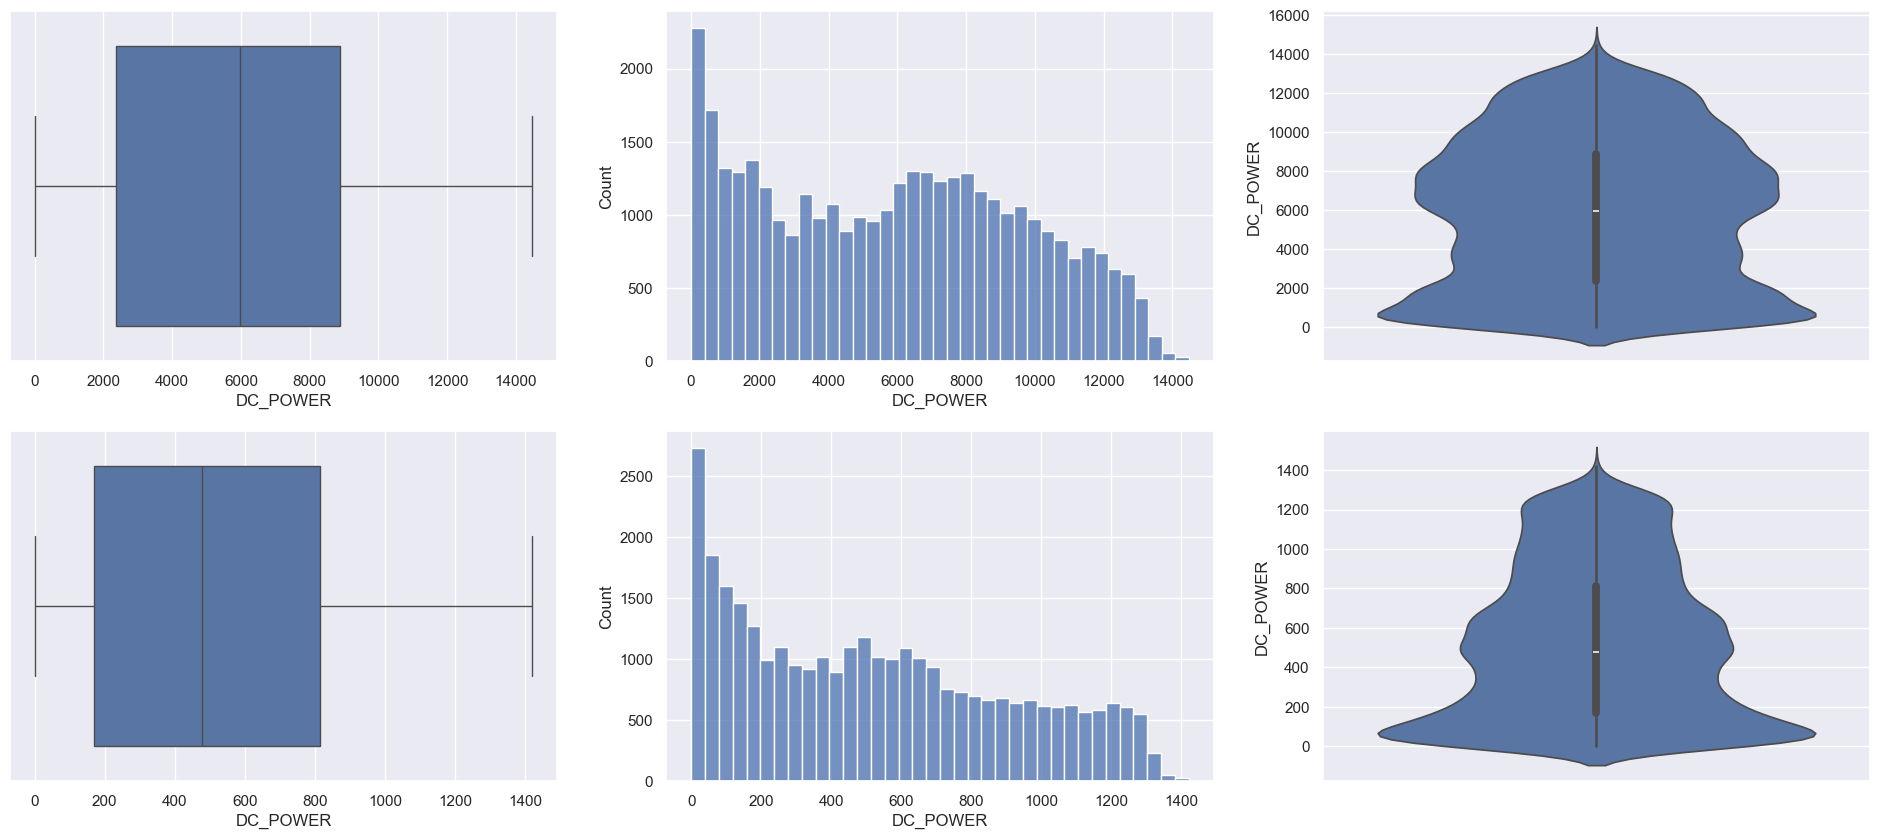

In [8]:
# Plot the basic uni-variate figures for DC power - plant 1 & 2
DC_stats = [p1_tmp['DC_POWER'], p2_tmp['DC_POWER']]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 10))
axis = 0
for value in DC_stats:
    sns.boxplot(data=value, orient = "h", ax = axes[axis,0])
    sns.histplot(data=value, kde = False, ax = axes[axis,1])
    sns.violinplot(data=value, ax = axes[axis,2])
    axis += 1

Notice the DC_POWER scaling is different for Plant 1 & Plant 2, a near 10x difference

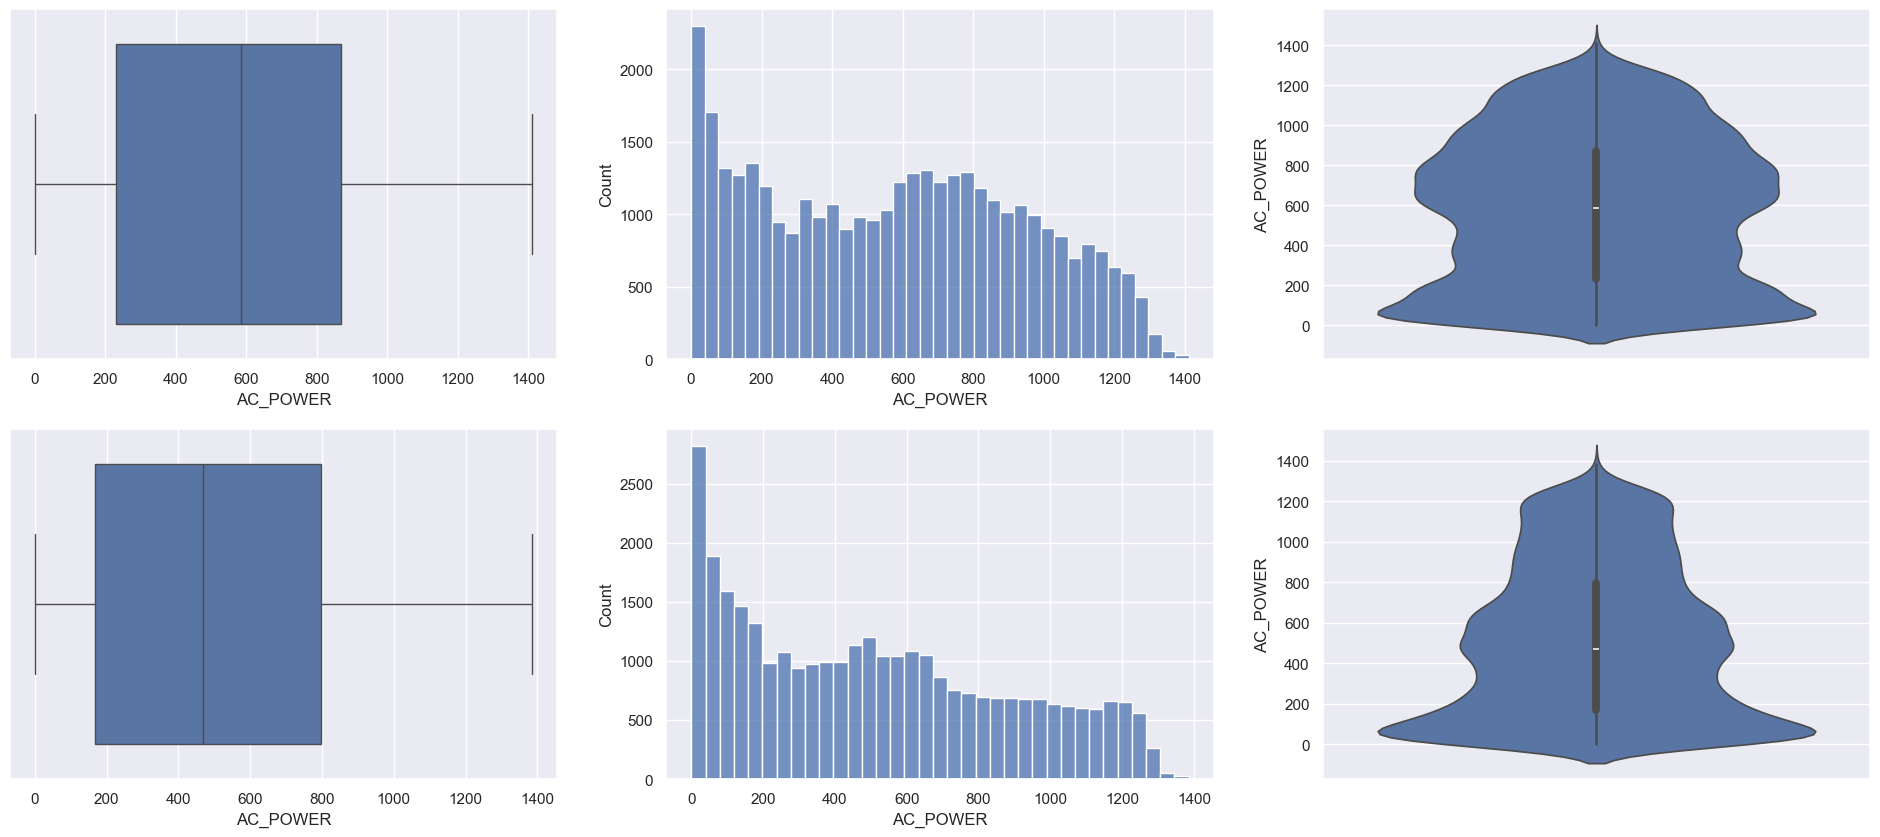

In [9]:
# Plot the basic uni-variate figures for AC power - plant 1 & 2
AC_stats = [p1_tmp['AC_POWER'], p2_tmp['AC_POWER']]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 10))
axis = 0
for value in AC_stats:
    sns.boxplot(data=value, orient = "h", ax = axes[axis,0]) # Define the axes [0,0] is the first subplot, [0,1] is second sublot in line 1...
    sns.histplot(data=value, kde = False, ax = axes[axis,1])
    sns.violinplot(data=value, ax = axes[axis,2])
    axis += 1


### Summary of Bug #1 Unit Mismatch Analysis

While Plant 2 shows an expected inverter AC/DC ratio of ~98%, which is generally acceptable for such applications, Plant 1 efficiency is not accurate as AC/DC ratio of 9.8% is highly unlikely.

<br>

Based on visualisation, Plants 1 & 2 AC values are recorded on the same scale with a maximum ~ 1400. For DC values however, Plant 2 data is consistent but Plant 1 DC appears about 10x larger shown in the boxplots and the maximum value. This could mean that Plant 1 DC may be recorded in different unit values to the rest.

<br>

A scale factor should be applied to Plant 1 DC to ensure all values are on the same scale, which is executed below.

### Bug #1 Unit Mismatch Fix

In [10]:
# Idempotent Plant 1 DC scaling: always calibrate from raw DC against Plant 2 efficiency
if 'DC_POWER_RAW' not in p1.columns:
    p1['DC_POWER_RAW'] = p1['DC_POWER']

p1_cal = p1[(p1['DC_POWER_RAW'] > 0) & (p1['AC_POWER'] > 0)].copy()
p2_cal = p2[(p2['DC_POWER'] > 0) & (p2['AC_POWER'] > 0)].copy()

p1_raw_ratio_median = (p1_cal['AC_POWER'] / p1_cal['DC_POWER_RAW']).median()
p2_ratio_median = (p2_cal['AC_POWER'] / p2_cal['DC_POWER']).median()

# Scale factor for: p1['DC_POWER'] = p1['DC_POWER_RAW'] / DC_SCALE_FACTOR
DC_SCALE_FACTOR = p2_ratio_median / p1_raw_ratio_median
print(f'DC scale factor (targeting P2 median AC/DC): {DC_SCALE_FACTOR:.4f}')

p1['DC_POWER'] = p1['DC_POWER_RAW'] / DC_SCALE_FACTOR

new_p1_median = (p1_cal['AC_POWER'] / (p1_cal['DC_POWER_RAW'] / DC_SCALE_FACTOR)).median()
print(f"New Plant 1 median AC/DC ratio after scaling: {new_p1_median:.4f}")
print(f"Target Plant 2 median AC/DC ratio           : {p2_ratio_median:.4f}")

corr = pd.DataFrame({
    'DC_scaled': p1_cal['DC_POWER_RAW'] / DC_SCALE_FACTOR,
    'AC_POWER': p1_cal['AC_POWER']
}).corr().iloc[0, 1]
print(f"Correlation of scaled P1 DC vs P1 AC: {corr:.6f}")

DC scale factor (targeting P2 median AC/DC): 9.9998
New Plant 1 median AC/DC ratio after scaling: 0.9784
Target Plant 2 median AC/DC ratio           : 0.9784
Correlation of scaled P1 DC vs P1 AC: 0.999993


In [11]:
# Summary statistics comparison
# Note that TOTAL_YIELD was excluded

summary = pd.DataFrame({
    'Metric': [
        'Mean AC Power (kW)', 'Max AC Power (kW)',
        'Mean DC Power (kW)', 'Total Inverters',
        'AC/DC Efficiency',
        'DAILY_YIELD mean'
    ],
    'Plant 1': [
        f"{p1['AC_POWER'].mean():.1f}",
        f"{p1['AC_POWER'].max():.1f}",
        f"{p1['DC_POWER'].mean():.1f}",
        f"{p1['SOURCE_KEY'].nunique()}",
        f"{(p1[p1['DC_POWER']>0]['AC_POWER'].sum()) / (p1[p1['DC_POWER']>0]['DC_POWER'].sum()):.4f}",
        f"{p1['DAILY_YIELD'].mean():.1f}"
    ],
    'Plant 2': [
        f"{p2['AC_POWER'].mean():.1f}",
        f"{p2['AC_POWER'].max():.1f}",
        f"{p2['DC_POWER'].mean():.1f}",
        f"{p2['SOURCE_KEY'].nunique()}",
        f"{(p2[p2['DC_POWER']>0]['AC_POWER'].sum()) / (p2[p2['DC_POWER']>0]['DC_POWER'].sum()):.4f}",
        f"{p2['DAILY_YIELD'].mean():.1f}"
    ]
})
display(summary)
print()

,Metric,Plant 1,Plant 2
0,Mean AC Power (kW),307.8,241.3
1,Max AC Power (kW),1411.0,1385.4
2,Mean DC Power (kW),314.7,246.7
3,Total Inverters,22,22
4,AC/DC Efficiency,0.9779,0.9780
5,DAILY_YIELD mean,3296.0,3294.9


Plant 1 AC/DC is now more plausible. Although the ratio has a value slightly > 1, this could be due to noise, or slight inaccuraccy in data readings that will account for this. In general the ratio would be less than 1, as there is slight inefficiencies in converting the power.

### Bug #2 Counter Overflow Analysis

In [12]:
# Total yield analysis
print('Plant 1 total yield description:')
display(p1['TOTAL_YIELD'].describe())
print('Plant 2 total yield description:')
display(p2['TOTAL_YIELD'].describe())

Plant 1 total yield description:


count    6.877800e+04
mean     6.978712e+06
std      4.162720e+05
min      6.183645e+06
25%      6.512003e+06
50%      7.146685e+06
75%      7.268706e+06
max      7.846821e+06
Name: TOTAL_YIELD, dtype: float64

Plant 2 total yield description:


count    6.769800e+04
mean     6.589448e+08
std      7.296678e+08
min      0.000000e+00
25%      1.996494e+07
50%      2.826276e+08
75%      1.348495e+09
max      2.247916e+09
Name: TOTAL_YIELD, dtype: float64

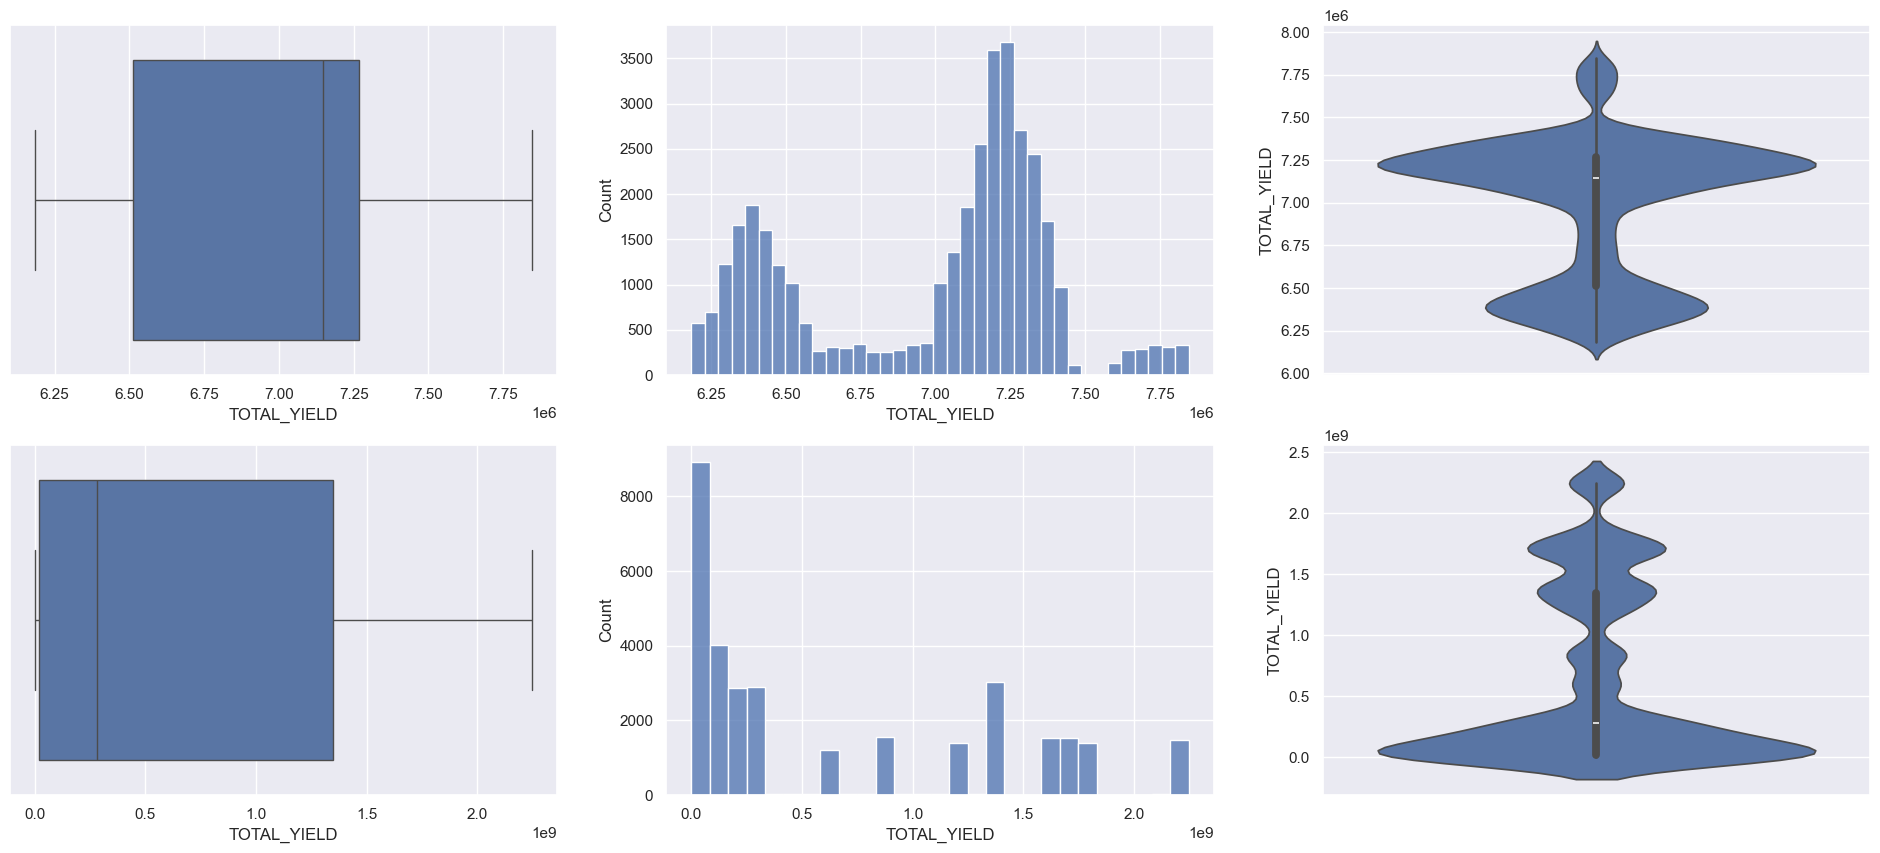

In [13]:
# Plot the basic uni-variate figures for total yield - plant 1 & 2
TOTAL_YIELD_stats = [p1_tmp['TOTAL_YIELD'], p2_tmp['TOTAL_YIELD']]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 10))
axis = 0
for value in TOTAL_YIELD_stats:
    sns.boxplot(data=value, orient = "h", ax = axes[axis,0])
    sns.histplot(data=value, kde = False, ax = axes[axis,1])
    sns.violinplot(data=value, ax = axes[axis,2])
    axis += 1

In [14]:
print(f"Plant 1 TOTAL_YIELD  max : {p1['TOTAL_YIELD'].max():,.0f}")
print(f"Plant 2 TOTAL_YIELD  max : {p2['TOTAL_YIELD'].max():,.0f}")
print(f"Plant 1 TOTAL_YIELD mean : {p1['TOTAL_YIELD'].mean():,.0f}")
print(f"Plant 2 TOTAL_YIELD mean : {p2['TOTAL_YIELD'].mean():,.0f}")

Plant 1 TOTAL_YIELD  max : 7,846,821
Plant 2 TOTAL_YIELD  max : 2,247,916,295
Plant 1 TOTAL_YIELD mean : 6,978,712
Plant 2 TOTAL_YIELD mean : 658,944,788


Inverters with TOTAL_YIELD > 78,468,210 (10× Plant 1 max): 16 / 22
Affected source keys: ['81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'NgDl19wMapZy17u', 'PeE6FRyGXUgsRhN', 'Qf4GUc1pJu5T6c6', 'Quc1TzYxW2pYoWX', 'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'mqwcsP2rE7J0TFp', 'oZ35aAeoifZaQzV', 'oZZkBaNadn6DNKz', 'rrq4fwE8jgrTyWY', 'xMbIugepa2P7lBB', 'xoJJ8DcxJEcupym']



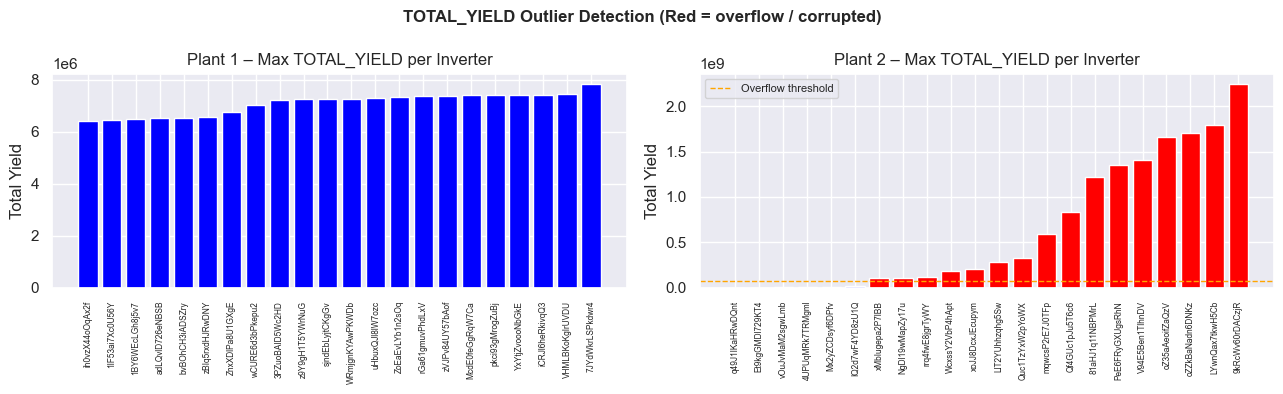

In [15]:
# Which inverters are affected?
threshold = p1['TOTAL_YIELD'].max() * 10   # 10x Plant 1's max shows clear outliers
bad_inv = p2[p2['TOTAL_YIELD'] > threshold]['SOURCE_KEY'].unique()
print(f"Inverters with TOTAL_YIELD > {threshold:,.0f} (10× Plant 1 max): {len(bad_inv)} / 22")
print("Affected source keys:", list(bad_inv))
print()

# Visualise the outlier scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, label in zip(axes, [p1, p2], ['Plant 1', 'Plant 2']):
    inv_max_yield = df.groupby('SOURCE_KEY')['TOTAL_YIELD'].max().sort_values()
    colors = ['red' if v > threshold else 'blue' for v in inv_max_yield]
    ax.bar(range(len(inv_max_yield)), inv_max_yield.values, color=colors)
    ax.set_title(f'{label} – Max TOTAL_YIELD per Inverter')
    ax.set_ylabel('Total Yield')
    ax.set_xticks(range(len(inv_max_yield)))
    ax.set_xticklabels(inv_max_yield.index, rotation=90, fontsize=6)
    if label == 'Plant 2':
        ax.axhline(threshold, color='orange', linestyle='--', linewidth=1, label=f'Overflow threshold')
        ax.legend(fontsize=8)
plt.suptitle('TOTAL_YIELD Outlier Detection (Red = overflow / corrupted)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

P2_OVERFLOW_INVERTERS = list(bad_inv)

### Summary of Bug #2 Counter Overflow Analysis

These outliers may be affected by counter overflow or reset bugs, affecting 16 of 22 inverters in plant 2.
Total yield is therefore not an effective variable to use in data handling and will be excluded from our data analysis. Daily yield, which is analysed below, will be used instead to avoid this.

### Bug #2 Counter Overflow Fix

In [16]:
# Daily yield analysis
print('Plant 1 daily yield description:')
display(p1['DAILY_YIELD'].describe())
print('Plant 2 daily yield description:')
display(p2['DAILY_YIELD'].describe())

Plant 1 daily yield description:


count    68778.000000
mean      3295.968737
std       3145.178309
min          0.000000
25%          0.000000
50%       2658.714286
75%       6274.000000
max       9163.000000
Name: DAILY_YIELD, dtype: float64

Plant 2 daily yield description:


count    67698.000000
mean      3294.890295
std       2919.448386
min          0.000000
25%        272.750000
50%       2911.000000
75%       5534.000000
max       9873.000000
Name: DAILY_YIELD, dtype: float64

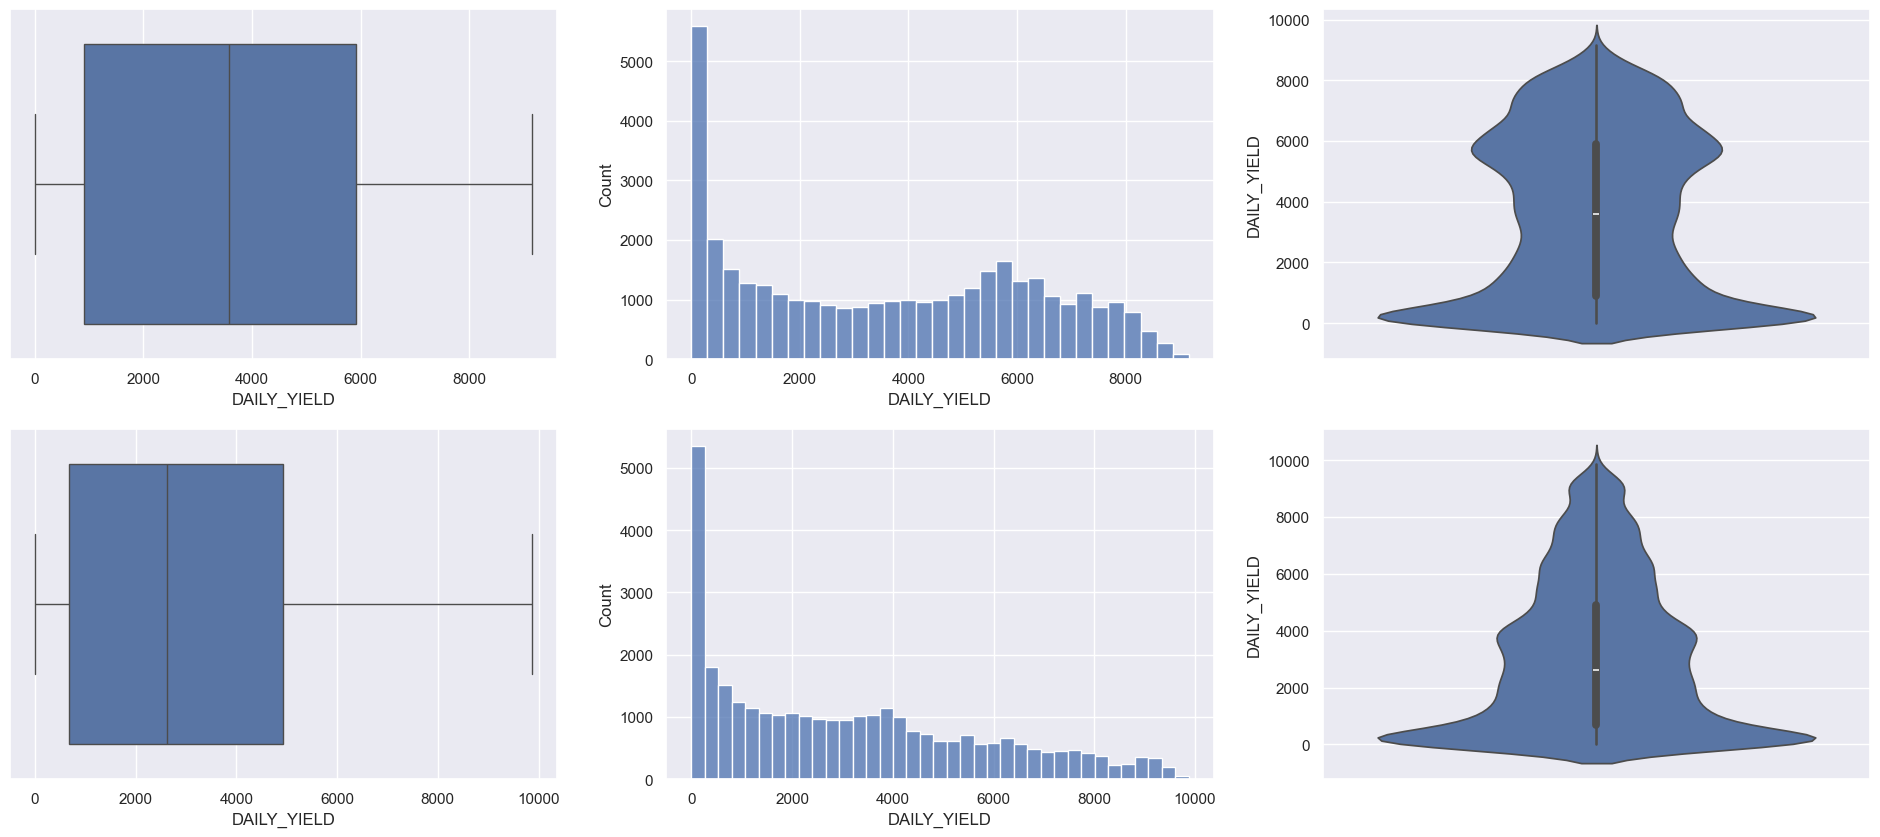

In [17]:
# Plot the basic uni-variate figures for daily yield - plant 1 & 2
DAILY_YIELD_stats = [p1_tmp['DAILY_YIELD'], p2_tmp['DAILY_YIELD']]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 10))
axis = 0
for value in DAILY_YIELD_stats:
    sns.boxplot(data=value, orient = "h", ax = axes[axis,0])
    sns.histplot(data=value, kde = False, ax = axes[axis,1])
    sns.violinplot(data=value, ax = axes[axis,2])
    axis += 1

In [18]:
print(f"Plant 1 DAILY_YIELD  max : {p1['DAILY_YIELD'].max():,.0f}")
print(f"Plant 2 DAILY_YIELD  max : {p2['DAILY_YIELD'].max():,.0f}")
print(f"Plant 1 DAILY_YIELD mean : {p1['DAILY_YIELD'].mean():,.0f}")
print(f"Plant 2 DAILY_YIELD mean : {p2['DAILY_YIELD'].mean():,.0f}")

Plant 1 DAILY_YIELD  max : 9,163
Plant 2 DAILY_YIELD  max : 9,873
Plant 1 DAILY_YIELD mean : 3,296
Plant 2 DAILY_YIELD mean : 3,295


The daily yield values of both Plants 1 and 2 are consistent and therefore is suitable to be used for further analysis in modelling later on.

---
## 4. Data Preprocessing & Feature Engineering

In [19]:
# ensure datetimes are all in the same format
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
p2['DATE_TIME'] = pd.to_datetime(p2['DATE_TIME'])
# Solar Recording: combine Date + Time
sr['datetime'] = pd.to_datetime(sr['Date'] + ' ' + sr['Time'], format='%m/%d/%Y %H:%M:%S')

print('Plant 1 range:', p1['DATE_TIME'].min(), '->', p1['DATE_TIME'].max())
print('Plant 2 range:', p2['DATE_TIME'].min(), '->', p2['DATE_TIME'].max())
print('SR range:     ', sr['datetime'].min(), '->', sr['datetime'].max())

Plant 1 range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Plant 2 range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
SR range:      2020-05-15 00:00:08 -> 2020-09-13 23:55:01


In [20]:
# Resample Solar Recording to 15-minute intervals to match plant data

# Step 1, set datetime as index and sort it in time order
sr_indexed = sr.set_index('datetime').sort_index()

weather_num_cols = ['Radiation', 'Temperature', 'Pressure', 'Humidity', 'WindDirection(Degrees)', 'Speed']

# Step 2, convert the data into 15-minute intervals
sr_15min = sr_indexed[weather_num_cols].resample('15min').mean().interpolate(method='linear') # Take the average within each 15-min window, if any time points are missing, fill them using linear interpolation
sr_15min = sr_15min.reset_index()
sr_15min.columns = ['DATE_TIME'] + weather_num_cols
print('Resampled weather data shape:', sr_15min.shape)
sr_15min.head()

Resampled weather data shape: (11712, 7)


,DATE_TIME,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,2020-05-15 00:00:00,2.705000,51.000000,30.430000,103.0,115.355000,10.125000
1,2020-05-15 00:15:00,2.185000,51.000000,30.430000,103.0,143.080000,12.935000
2,2020-05-15 00:30:00,2.250000,51.000000,30.430000,103.0,67.420000,11.250000
3,2020-05-15 00:45:00,2.093333,51.333333,30.430000,103.0,98.136667,4.496667
4,2020-05-15 01:00:00,2.090000,51.666667,30.423333,103.0,106.126667,4.500000


In [21]:
# Combine plant data to plant level (sum across inverters in each plant per timestamp)
def aggregate_plant(df, plant_id_label):
    agg = df.groupby('DATE_TIME').agg(
        DC_POWER=('DC_POWER', 'sum'),
        AC_POWER=('AC_POWER', 'sum'),
        DAILY_YIELD=('DAILY_YIELD', 'mean') # DAILY_YIELD is already per inverter cumulative value, summing would be double counting. Mean is used instead.
    ).reset_index()
    agg['PLANT'] = plant_id_label
    return agg

p1_agg = aggregate_plant(p1, 'Plant_1')
p2_agg = aggregate_plant(p2, 'Plant_2')


print('Plant 1 Aggregated Data:')
print('Shape:', p1_agg.shape)
display(p1_agg.head(3))

print('\nPlant 2 Aggregated Data:')
print('Shape:', p2_agg.shape)
display(p2_agg.head(3))

Plant 1 Aggregated Data:
Shape: (3158, 5)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,PLANT
0,2020-05-15 00:00:00,0.0,0.0,0.0,Plant_1
1,2020-05-15 00:15:00,0.0,0.0,0.0,Plant_1
2,2020-05-15 00:30:00,0.0,0.0,0.0,Plant_1



Plant 2 Aggregated Data:
Shape: (3259, 5)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,PLANT
0,2020-05-15 00:00:00,0.0,0.0,2222.724459,Plant_2
1,2020-05-15 00:15:00,0.0,0.0,1290.954545,Plant_2
2,2020-05-15 00:30:00,0.0,0.0,1290.954545,Plant_2


It is noted here that Plant 2 Aggregated Data shows a non-zero daily yield value at midnight of 2020-05-15 compared to that of Plant 1. This is not a matter of concern however, as this observation aligns with the raw DAILY_YIELD data from Plant_2_Generation_Data.csv.

<br>

Considering DAILY_YIELD is a cumulative variable, this may be indicative of how the dataset may already have been pre-processed such that both plants' data begin from 2020-05-15.

In [22]:
# Merge plant data with weather data
def merge_with_weather(plant_agg, weather_df):
    merged = pd.merge_asof(
        plant_agg.sort_values('DATE_TIME'),
        weather_df.sort_values('DATE_TIME'),
        on='DATE_TIME',
        tolerance=pd.Timedelta('15min'),
        direction='nearest'
    )
# radiation is the most important weather factor, so if there are no recordings for this, we will drop the recording to ensure reliable predictions down the line.
    merged = merged.dropna(subset=['Radiation'])
    return merged

p1_merged = merge_with_weather(p1_agg, sr_15min)
p2_merged = merge_with_weather(p2_agg, sr_15min)

print('Plant 1 Merged Data:')
print('Shape:', p1_merged.shape)
display(p1_merged.head(3))

print('\nPlant 2 Merged Data:')
print('Shape:', p2_merged.shape)
display(p2_merged.head(3))

Plant 1 Merged Data:
Shape: (3158, 11)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,PLANT,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,2020-05-15 00:00:00,0.0,0.0,0.0,Plant_1,2.705,51.0,30.43,103.0,115.355,10.125
1,2020-05-15 00:15:00,0.0,0.0,0.0,Plant_1,2.185,51.0,30.43,103.0,143.080,12.935
2,2020-05-15 00:30:00,0.0,0.0,0.0,Plant_1,2.250,51.0,30.43,103.0,67.420,11.250



Plant 2 Merged Data:
Shape: (3259, 11)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,PLANT,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
0,2020-05-15 00:00:00,0.0,0.0,2222.724459,Plant_2,2.705,51.0,30.43,103.0,115.355,10.125
1,2020-05-15 00:15:00,0.0,0.0,1290.954545,Plant_2,2.185,51.0,30.43,103.0,143.080,12.935
2,2020-05-15 00:30:00,0.0,0.0,1290.954545,Plant_2,2.250,51.0,30.43,103.0,67.420,11.250


In [23]:
# Feature Engineering
def add_time_features(df):
    df = df.copy()
    df['hour'] = df['DATE_TIME'].dt.hour
    df['month'] = df['DATE_TIME'].dt.month
    df['dayofyear'] = df['DATE_TIME'].dt.dayofyear
    # Solar hour angle proxy (how far from solar noon)
    df['hour_from_noon'] = (df['hour'] - 12).abs()
    # Remove night time rows - no solar generation
    df = df[df['Radiation'] > 10].copy()
    return df

p1_feat = add_time_features(p1_merged)
p2_feat = add_time_features(p2_merged)

print('Plant 1 daytime rows:', p1_feat.shape[0])
print('Plant 2 daytime rows:', p2_feat.shape[0])

Plant 1 daytime rows: 1587
Plant 2 daytime rows: 1611


---
## 5. Explore the Processed Data

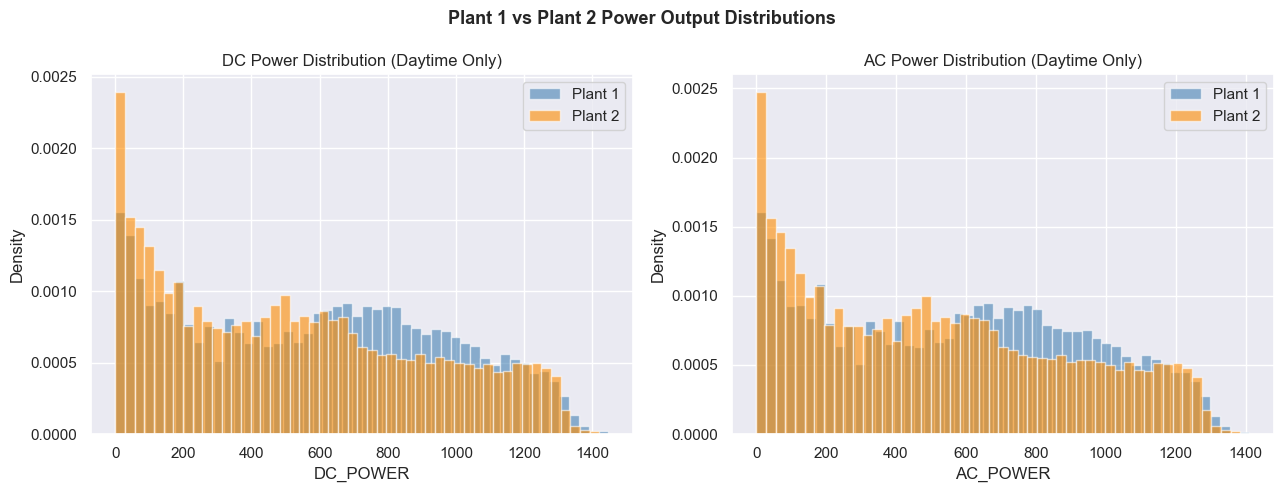

In [24]:
# DC/AC Power distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes, ['DC_POWER', 'AC_POWER'], ['DC Power', 'AC Power']):
    # Filter positive values only
    d1 = p1[p1[col] > 0][col]
    d2 = p2[p2[col] > 0][col]
    ax.hist(d1, bins=50, alpha=0.6, label='Plant 1', color='steelblue', density=True)
    ax.hist(d2, bins=50, alpha=0.6, label='Plant 2', color='darkorange', density=True)
    ax.set_title(f'{title} Distribution (Daytime Only)')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Plant 1 vs Plant 2 Power Output Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

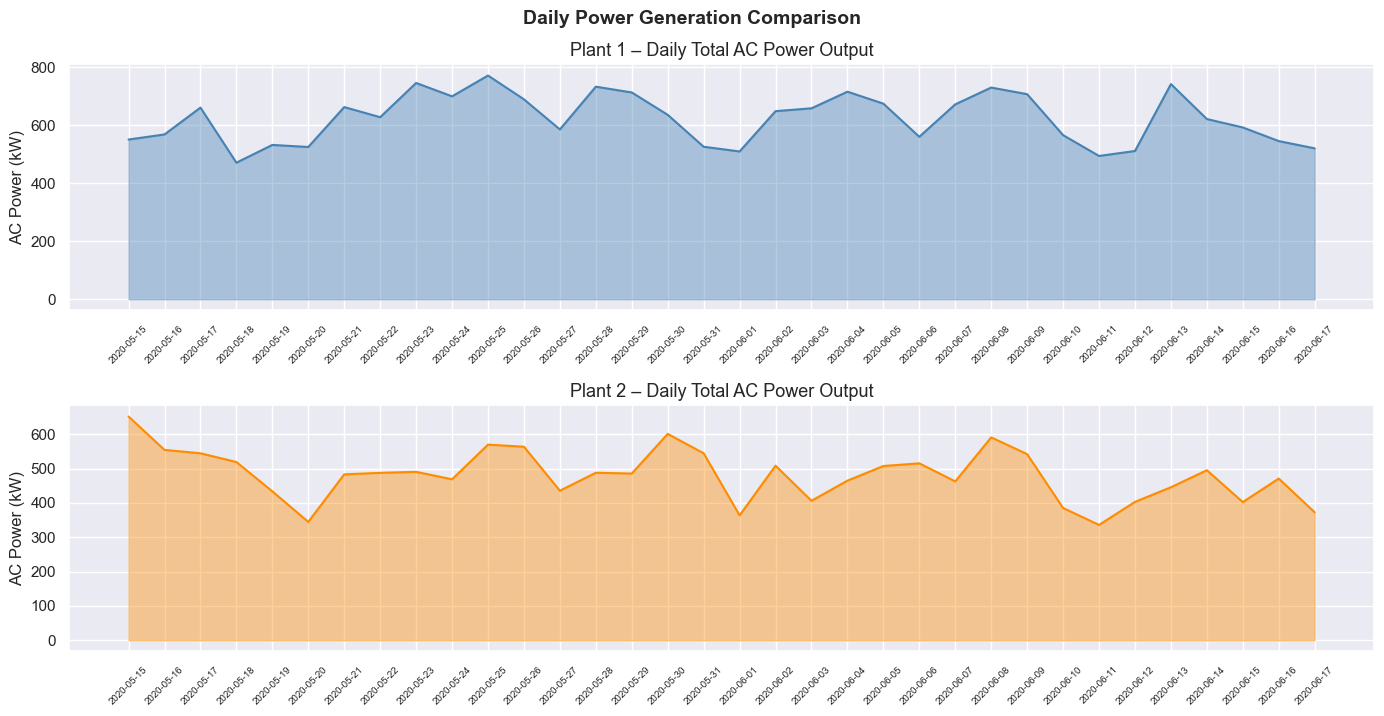

In [25]:
# Daily AC Power generation over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, df, label, color in zip(axes, [p1_merged, p2_merged], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']): # full datasets containing all time periods i.e. p1_merged and p2_merged used to ensure accurate visualisation of total power generation
    hourly = df.groupby(df['DATE_TIME'].dt.hour)['AC_POWER'].mean()
    daily = df.groupby(df['DATE_TIME'].dt.date)['AC_POWER'].sum() / 1000  # convert to kW
    ax.fill_between(range(len(daily)), daily.values, alpha=0.4, color=color)
    ax.plot(range(len(daily)), daily.values, color=color, linewidth=1.5)
    ax.set_title(f'{label} – Daily Total AC Power Output', fontsize=13)
    ax.set_ylabel('AC Power (kW)')
    ax.set_xticks(range(len(daily)))
    ax.set_xticklabels([str(d) for d in daily.index], rotation=45, fontsize=7)

plt.tight_layout()
plt.suptitle('Daily Power Generation Comparison', y=1.02, fontsize=14, fontweight='bold')
plt.show()

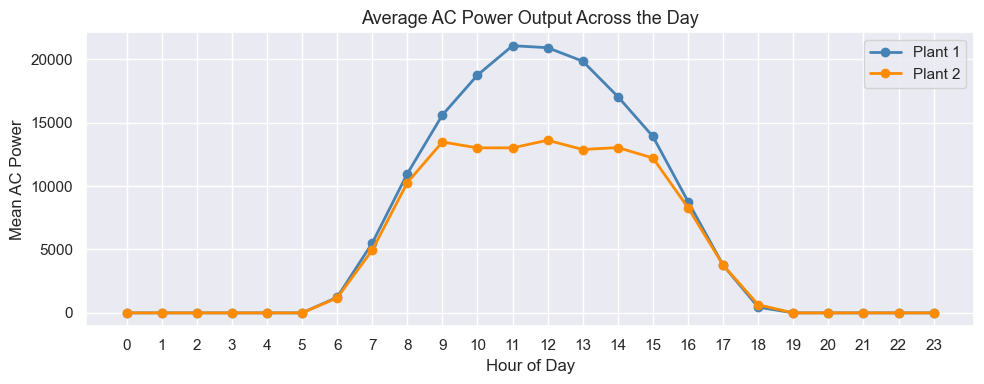

In [26]:
# Average AC Power by Hour of Day
fig, ax = plt.subplots(figsize=(10, 4))

for df, label, color in zip([p1_merged, p2_merged], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']):
    hourly = df.groupby(df['DATE_TIME'].dt.hour)['AC_POWER'].mean()
    ax.plot(hourly.index, hourly.values, marker='o', label=label, color=color, linewidth=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean AC Power')
ax.set_title('Average AC Power Output Across the Day', fontsize=13)
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

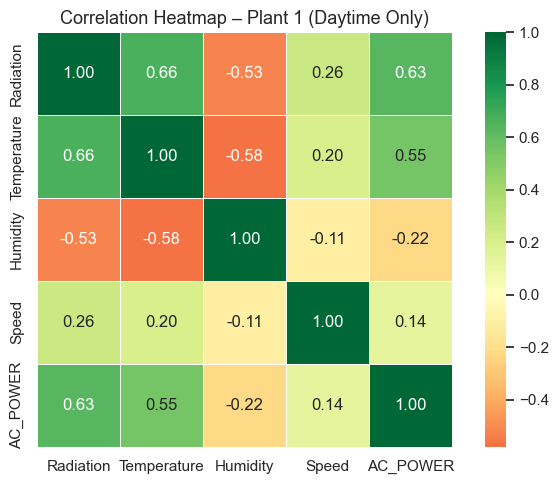

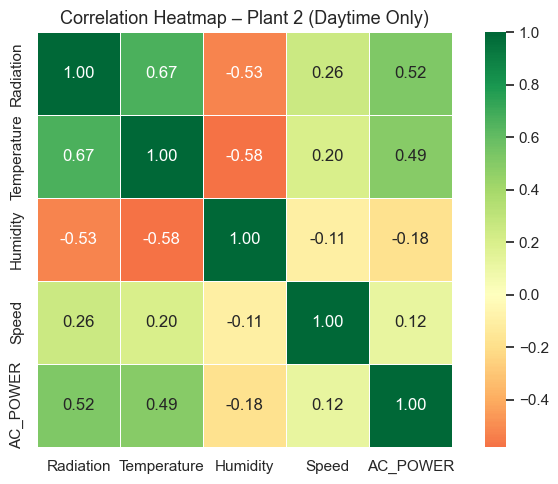

In [27]:
#Correlation heatmap: weather features vs AC Power (Plant 1)
corr_cols = ['Radiation', 'Temperature', 'Humidity', 'Speed', 'AC_POWER']
corr_data_1 = p1_feat[corr_cols].corr()
corr_data_2 = p2_feat[corr_cols].corr()


plt.figure(figsize=(7, 5))
sns.heatmap(corr_data_1, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap – Plant 1 (Daytime Only)', fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_data_2, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap – Plant 2 (Daytime Only)', fontsize=13)
plt.tight_layout()
plt.show()

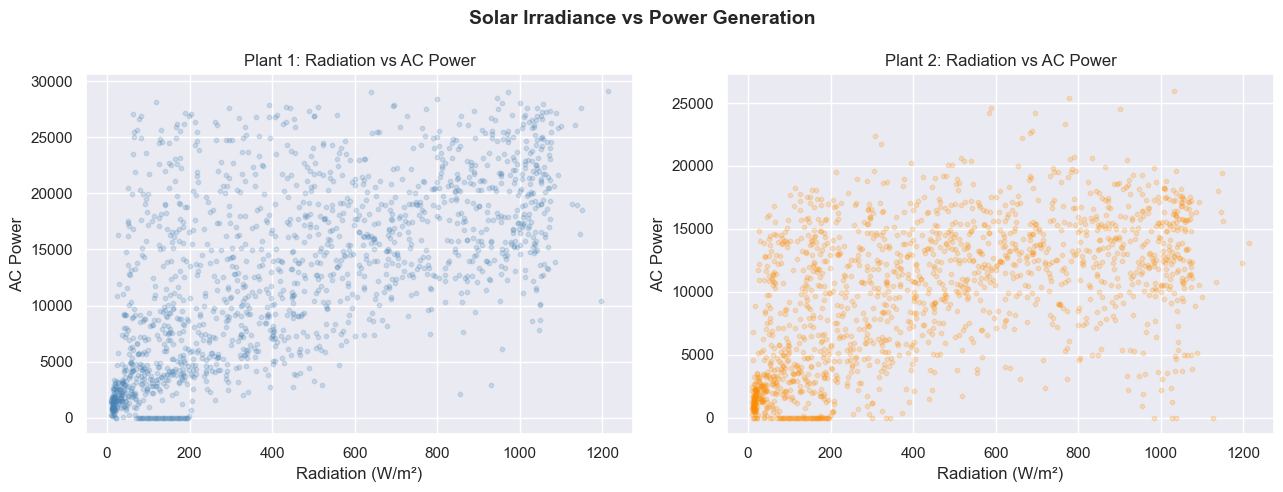

In [28]:
# Radiation vs AC Power scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in zip(axes, [p1_feat, p2_feat], ['Plant 1', 'Plant 2'], ['steelblue', 'darkorange']):
    ax.scatter(df['Radiation'], df['AC_POWER'], alpha=0.2, s=10, color=color)
    ax.set_xlabel('Radiation (W/m²)')
    ax.set_ylabel('AC Power')
    ax.set_title(f'{label}: Radiation vs AC Power')

plt.suptitle('Solar Irradiance vs Power Generation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

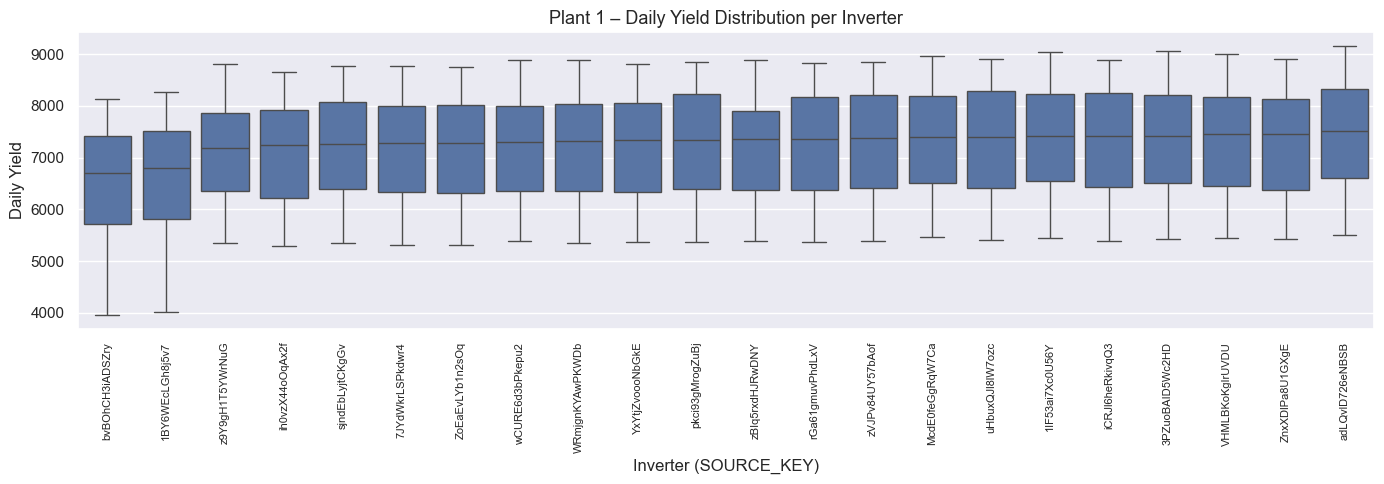

In [29]:
# Per-inverter daily yield distribution (Plant 1)
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
p1_daily_inv = p1.groupby(['SOURCE_KEY', p1['DATE_TIME'].dt.date])['DAILY_YIELD'].max().reset_index()
p1_daily_inv.columns = ['SOURCE_KEY', 'Date', 'DAILY_YIELD']

plt.figure(figsize=(14, 5))
inv_order = p1_daily_inv.groupby('SOURCE_KEY')['DAILY_YIELD'].median().sort_values()
sns.boxplot(data=p1_daily_inv, x='SOURCE_KEY', y='DAILY_YIELD', order=inv_order.index)
plt.xticks(rotation=90, fontsize=8)
plt.title('Plant 1 – Daily Yield Distribution per Inverter', fontsize=13)
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Daily Yield')
plt.tight_layout()
plt.show()

Inverters on the left have consistently lower yields, indicating potential underperformers

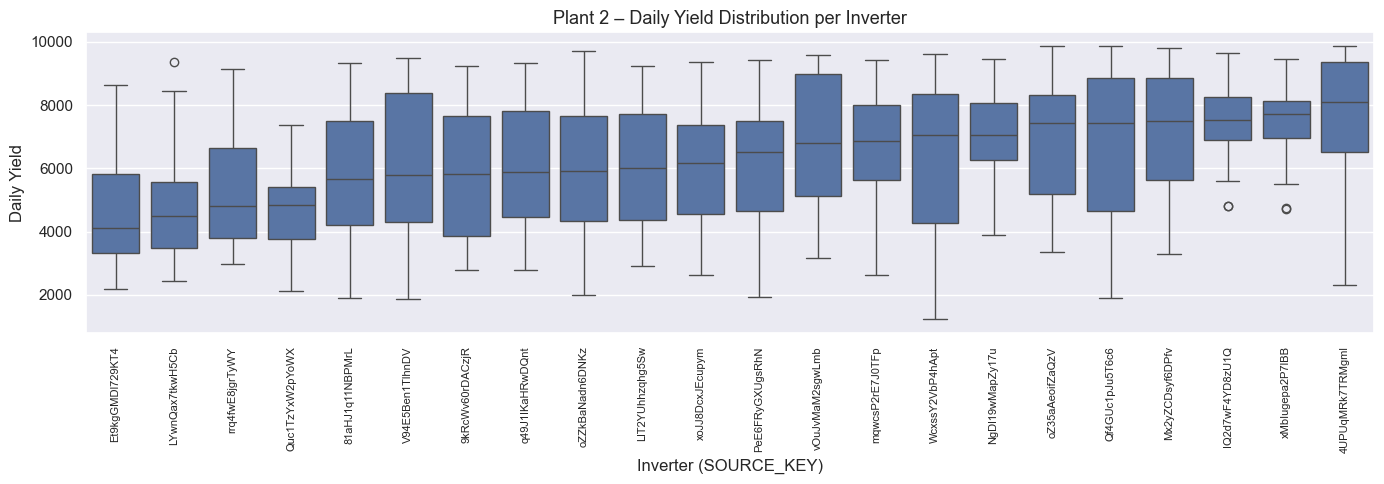

In [30]:
# Per-inverter daily yield distribution (Plant 2)
p2['DATE_TIME'] = pd.to_datetime(p2['DATE_TIME'], dayfirst=True)
p2_daily_inv = p2.groupby(['SOURCE_KEY', p2['DATE_TIME'].dt.date])['DAILY_YIELD'].max().reset_index()
p2_daily_inv.columns = ['SOURCE_KEY', 'Date', 'DAILY_YIELD']

plt.figure(figsize=(14, 5))
inv_order = p2_daily_inv.groupby('SOURCE_KEY')['DAILY_YIELD'].median().sort_values()
sns.boxplot(data=p2_daily_inv, x='SOURCE_KEY', y='DAILY_YIELD', order=inv_order.index)
plt.xticks(rotation=90, fontsize=8)
plt.title('Plant 2 – Daily Yield Distribution per Inverter', fontsize=13)
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Daily Yield')
plt.tight_layout()
plt.show()

Plant 2 is overall less consistent than Plant 1

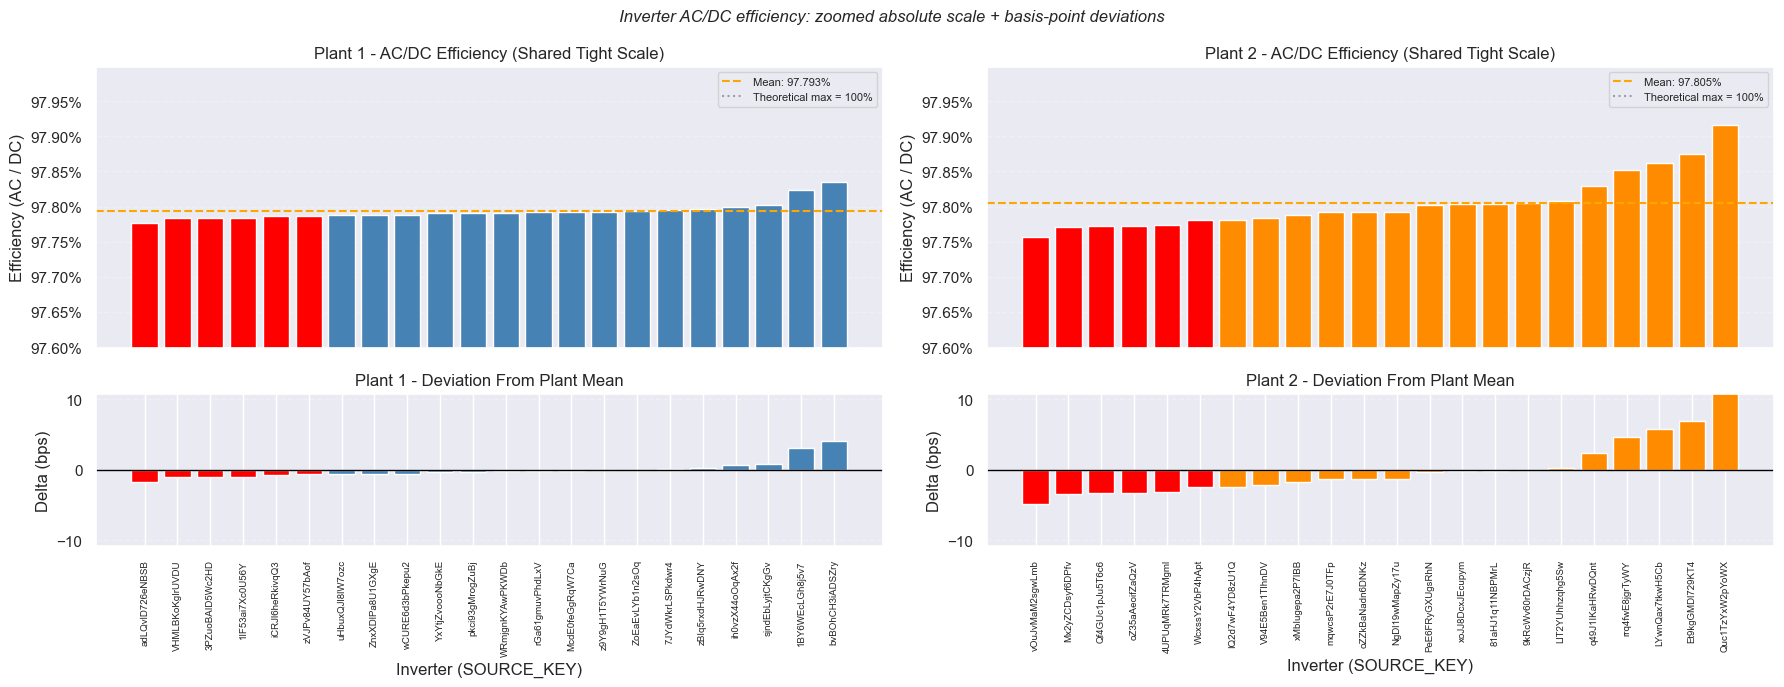

In [33]:
# AC-DC efficiency per inverter — high-resolution comparison
import matplotlib.ticker as mtick

plant_specs = [
    (p1, 'Plant 1', 'steelblue'),
    (p2, 'Plant 2', 'darkorange')
]

inv_data = []
for df, label, color in plant_specs:
    inv_stats = df.groupby('SOURCE_KEY').agg(
        mean_DC=('DC_POWER', 'mean'),
        mean_AC=('AC_POWER', 'mean')
    ).reset_index()
    inv_stats = inv_stats[inv_stats['mean_DC'] > 0].copy()
    inv_stats['efficiency'] = inv_stats['mean_AC'] / (inv_stats['mean_DC'] + 1e-9)
    inv_stats = inv_stats[inv_stats['efficiency'].between(0.90, 1.05)].copy()
    inv_stats = inv_stats.sort_values('efficiency').reset_index(drop=True)

    mean_eff = inv_stats['efficiency'].mean()
    inv_stats['delta_bps'] = (inv_stats['efficiency'] - mean_eff) * 10000
    inv_stats['is_low_q'] = inv_stats['efficiency'] < inv_stats['efficiency'].quantile(0.25)
    inv_data.append((label, color, inv_stats, mean_eff))

# Shared tight y-scale across both plants for fair visual comparison
all_eff = pd.concat([d[2]['efficiency'] for d in inv_data], ignore_index=True)
q005, q995 = all_eff.quantile([0.005, 0.995])
pad = max(0.0008, (q995 - q005) * 0.15)
y_min = max(0.94, q005 - pad)
y_max = min(1.01, q995 + pad)
if y_max - y_min < 0.004:
    center = all_eff.mean()
    y_min, y_max = center - 0.002, center + 0.002

# Shared delta range (in basis points) for the lower panels
max_abs_bps = max(float(d[2]['delta_bps'].abs().quantile(0.98)) for d in inv_data)
max_abs_bps = max(5.0, max_abs_bps)

fig, axes = plt.subplots(
    2, 2, figsize=(18, 7),
    gridspec_kw={'height_ratios': [2.4, 1.3]}
)

for col, (label, color, inv_stats, mean_eff) in enumerate(inv_data):
    x = np.arange(len(inv_stats))
    bar_colors = ['red' if low else color for low in inv_stats['is_low_q']]

    # Top row: absolute efficiency with tight shared scale
    ax_top = axes[0, col]
    ax_top.bar(x, inv_stats['efficiency'], color=bar_colors)
    ax_top.axhline(mean_eff, color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {mean_eff:.3%}')
    ax_top.axhline(1.0, color='gray', linestyle=':', alpha=0.7, label='Theoretical max = 100%')
    ax_top.set_ylim(y_min, y_max)
    ax_top.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
    ax_top.grid(axis='y', alpha=0.25, linestyle='--')
    ax_top.set_title(f'{label} - AC/DC Efficiency (Shared Tight Scale)')
    ax_top.set_ylabel('Efficiency (AC / DC)')
    ax_top.set_xticks([])
    ax_top.legend(fontsize=8)

    # Bottom row: deviation from plant mean in basis points
    ax_bot = axes[1, col]
    ax_bot.bar(x, inv_stats['delta_bps'], color=bar_colors)
    ax_bot.axhline(0, color='black', linewidth=1)
    ax_bot.set_ylim(-1.15 * max_abs_bps, 1.15 * max_abs_bps)
    ax_bot.grid(axis='y', alpha=0.25, linestyle='--')
    ax_bot.set_title(f'{label} - Deviation From Plant Mean')
    ax_bot.set_ylabel('Delta (bps)')
    ax_bot.set_xlabel('Inverter (SOURCE_KEY)')
    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels(inv_stats['SOURCE_KEY'], rotation=90, fontsize=7)

plt.suptitle('Inverter AC/DC efficiency: zoomed absolute scale + basis-point deviations', fontsize=12, fontstyle='italic')
plt.tight_layout()
plt.show()


## 6. Regression – Predicting AC Power from Weather Features

In [34]:
FEATURES = ['Radiation', 'Temperature', 'Humidity', 'Speed', 'hour', 'hour_from_noon', 'month']
TARGET   = 'AC_POWER'

# Plant 1 train/test split
p1_feat_s = p1_feat.sort_values('DATE_TIME').reset_index(drop=True)
X1 = p1_feat_s[FEATURES]
y1 = p1_feat_s[TARGET]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Plant 2 train/test split
p2_feat_s = p2_feat.sort_values('DATE_TIME').reset_index(drop=True)
X2 = p2_feat_s[FEATURES]
y2 = p2_feat_s[TARGET]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f'Plant 1 — Train: {X1_train.shape[0]}  |  Test: {X1_test.shape[0]}')
print(f'Plant 2 — Train: {X2_train.shape[0]}  |  Test: {X2_test.shape[0]}')
print()
print(f'P1 mean AC (daytime): {y1.mean():.0f}')
print(f'P2 mean AC (daytime): {y2.mean():.0f}')
print(f'Scale ratio P1/P2:    {y1.mean()/y2.mean():.2f}')

Plant 1 — Train: 1269  |  Test: 318
Plant 2 — Train: 1288  |  Test: 323

P1 mean AC (daytime): 12844
P2 mean AC (daytime): 9820
Scale ratio P1/P2:    1.31


Each plant is trained and evaluated on its own data.
Plant 1 produces ~30% more AC power per inverter at the same radiation level, so a model trained on Plant 1 cannot be
applied to Plant 2 directly.
This can be verified with a cross-plant transfer test.

In [35]:
def make_models():
    return {
        'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_leaf=3, random_state=42, n_jobs=-1),
    }

# Cross-transfer test: train on P1, predict P2
print("Cross-transfer test (use train P1 to predict P2)")
models_p1 = make_models()
cross_results = []
for name, model in models_p1.items():
    model.fit(X1_train, y1_train)
    r2_p1  = r2_score(y1_test, model.predict(X1_test))
    r2_p2x = r2_score(y2, model.predict(X2))          # cross-plant
    cross_results.append({'Model': name, 'P1 R2 (own)': r2_p1, 'P2 R2 (cross)': r2_p2x})
    print(f'{name:22s}  P1 R²={r2_p1:.4f}  |  P2 R² (cross)={r2_p2x:.4f}')

Cross-transfer test (use train P1 to predict P2)
Linear Regression       P1 R²=0.7035  |  P2 R² (cross)=0.0216
Random Forest           P1 R²=0.7978  |  P2 R² (cross)=0.0269


In [36]:
print("Cross-transfer fails because P1 and P2 have different installed capacity.")
print(f"P1 generates {y1.mean()/y2.mean():.2f}x more AC than P2 at the same radiation level.")
print("The P1 model systematically over-predicts P2, giving near-zero or negative R2.")

Cross-transfer fails because P1 and P2 have different installed capacity.
P1 generates 1.31x more AC than P2 at the same radiation level.
The P1 model systematically over-predicts P2, giving near-zero or negative R2.


In [37]:
# each plant trained on its own data
print("Separate model per plant")
models_p1 = make_models()
models_p2 = make_models()
results = []

for name in models_p1: # there are two models in models_p1(make_models): linear reg, random forest
    m1 = models_p1[name]; m1.fit(X1_train, y1_train)
    m2 = models_p2[name]; m2.fit(X2_train, y2_train)

    r2_1  = r2_score(y1_test,  m1.predict(X1_test))
    rms_1 = np.sqrt(mean_squared_error(y1_test, m1.predict(X1_test)))
    mae_1 = mean_absolute_error(y1_test, m1.predict(X1_test))

    r2_2  = r2_score(y2_test,  m2.predict(X2_test))
    rms_2 = np.sqrt(mean_squared_error(y2_test, m2.predict(X2_test)))
    mae_2 = mean_absolute_error(y2_test, m2.predict(X2_test))

    results.append({'Model': name,
                    'R2 P1': r2_1, 'RMSE P1': rms_1, 'MAE P1': mae_1,
                    'R2 P2': r2_2, 'RMSE P2': rms_2, 'MAE P2': mae_2})
    print(f'{name:22s}  P1: R²={r2_1:.4f} RMSE={rms_1:.0f}  |  P2: R²={r2_2:.4f} RMSE={rms_2:.0f}')

print()

results_df = pd.DataFrame(results)
display(results_df.round(4))

Separate model per plant
Linear Regression       P1: R²=0.7035 RMSE=4376  |  P2: R²=0.5231 RMSE=3888
Random Forest           P1: R²=0.7978 RMSE=3613  |  P2: R²=0.6427 RMSE=3366



,Model,R2 P1,RMSE P1,MAE P1,R2 P2,RMSE P2,MAE P2
0,Linear Regression,0.7035,4375.9840,3490.9362,0.5231,3888.4644,2972.8040
1,Random Forest,0.7978,3613.2788,2719.0201,0.6427,3365.7939,2360.7065


In [38]:
# Since Random Forest performs better than the Linear Regression model, it is kept as the best model for downstream use
best_model_p1 = models_p1['Random Forest']
best_model_p2 = models_p2['Random Forest']

In [39]:
m1 = best_model_p1; m1.fit(X1_train, y1_train)
m2 = best_model_p2; m2.fit(X2_train, y2_train)

# Train scores
r2_1_train  = r2_score(y1_train, m1.predict(X1_train))
rmse_1_train = np.sqrt(mean_squared_error(y1_train, m1.predict(X1_train)))
mae_1_train  = mean_absolute_error(y1_train, m1.predict(X1_train))

r2_2_train  = r2_score(y2_train, m2.predict(X2_train))
rmse_2_train = np.sqrt(mean_squared_error(y2_train, m2.predict(X2_train)))
mae_2_train  = mean_absolute_error(y2_train, m2.predict(X2_train))


# Test scores
r2_1_test  = r2_score(y1_test, m1.predict(X1_test))
rmse_1_test = np.sqrt(mean_squared_error(y1_test, m1.predict(X1_test)))
mae_1_test  = mean_absolute_error(y1_test, m1.predict(X1_test))

r2_2_test  = r2_score(y2_test, m2.predict(X2_test))
rmse_2_test = np.sqrt(mean_squared_error(y2_test, m2.predict(X2_test)))
mae_2_test  = mean_absolute_error(y2_test, m2.predict(X2_test))


p1_table = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R2': [r2_1_train, r2_1_test],
    'RMSE': [rmse_1_train, rmse_1_test]
})
print('Goodness of Fit of Plant 1:')
display(p1_table.round(4))
print()

p2_table = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R2': [r2_2_train, r2_2_test],
    'RMSE': [rmse_2_train, rmse_2_test]
})
print('Goodness of Fit of Plant 2:')
display(p2_table.round(4))

Goodness of Fit of Plant 1:


,Dataset,R2,RMSE
0,Train,0.8178,3349.7801
1,Test,0.7978,3613.2788



Goodness of Fit of Plant 2:


,Dataset,R2,RMSE
0,Train,0.7256,2962.9357
1,Test,0.6427,3365.7939


In [40]:
# understand correlation between radiation and the power for both plants
print(f'  Radiation–AC correlation  P1: {X1.corrwith(y1)["Radiation"]:.4f}  P2: {X2.corrwith(y2)["Radiation"]:.4f}')

  Radiation–AC correlation  P1: 0.6325  P2: 0.5217


Radiation explains less of Plant 2 variance, possibly due to panel faults, identified in the anomaly detection

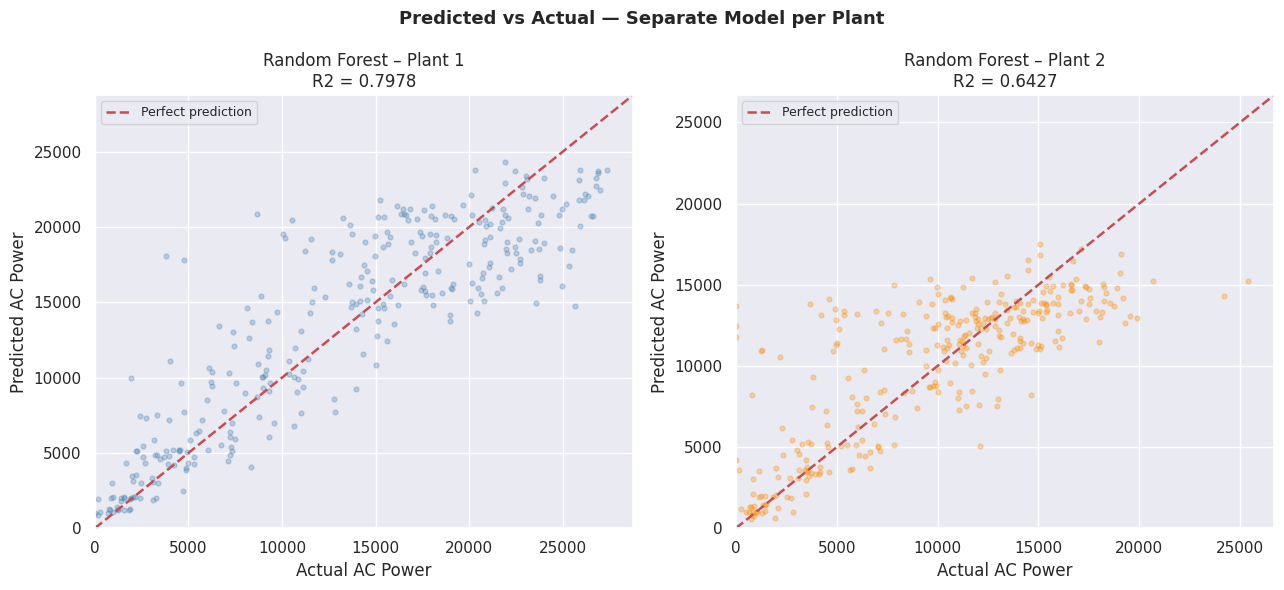

In [ ]:
# Predicted vs Actual — Random Forest, both plants
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, model, X_te, y_te, label, color in [
    (axes[0], best_model_p1, X1_test, y1_test, 'Plant 1', 'steelblue'),
    (axes[1], best_model_p2, X2_test, y2_test, 'Plant 2', 'darkorange'),
]:
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    lims = [0, max(y_te.max(), y_pred.max()) * 1.05]
    ax.scatter(y_te, y_pred, alpha=0.3, s=12, color=color)
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual AC Power')
    ax.set_ylabel('Predicted AC Power')
    ax.set_title(f'Random Forest – {label}\nR2 = {r2:.4f}', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual — Separate Model per Plant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Although Random Forest outperforms Linear Regression in predictive accuracy, it is less interpretable because it relies on an ensemble of decision trees rather than a simple mathematical equation. It is also non-parametric, meaning it does not assume a specific functional relationship between variables.

<br>

Therefore, an attempt to improve interpretability is conducted through feature importance below. Feature importance can improve the interpretability of Random Forest by highlighting which variables are most influential, but it does not fully explain how those variables affect the prediction, so the model remains less interpretable than linear regression still.

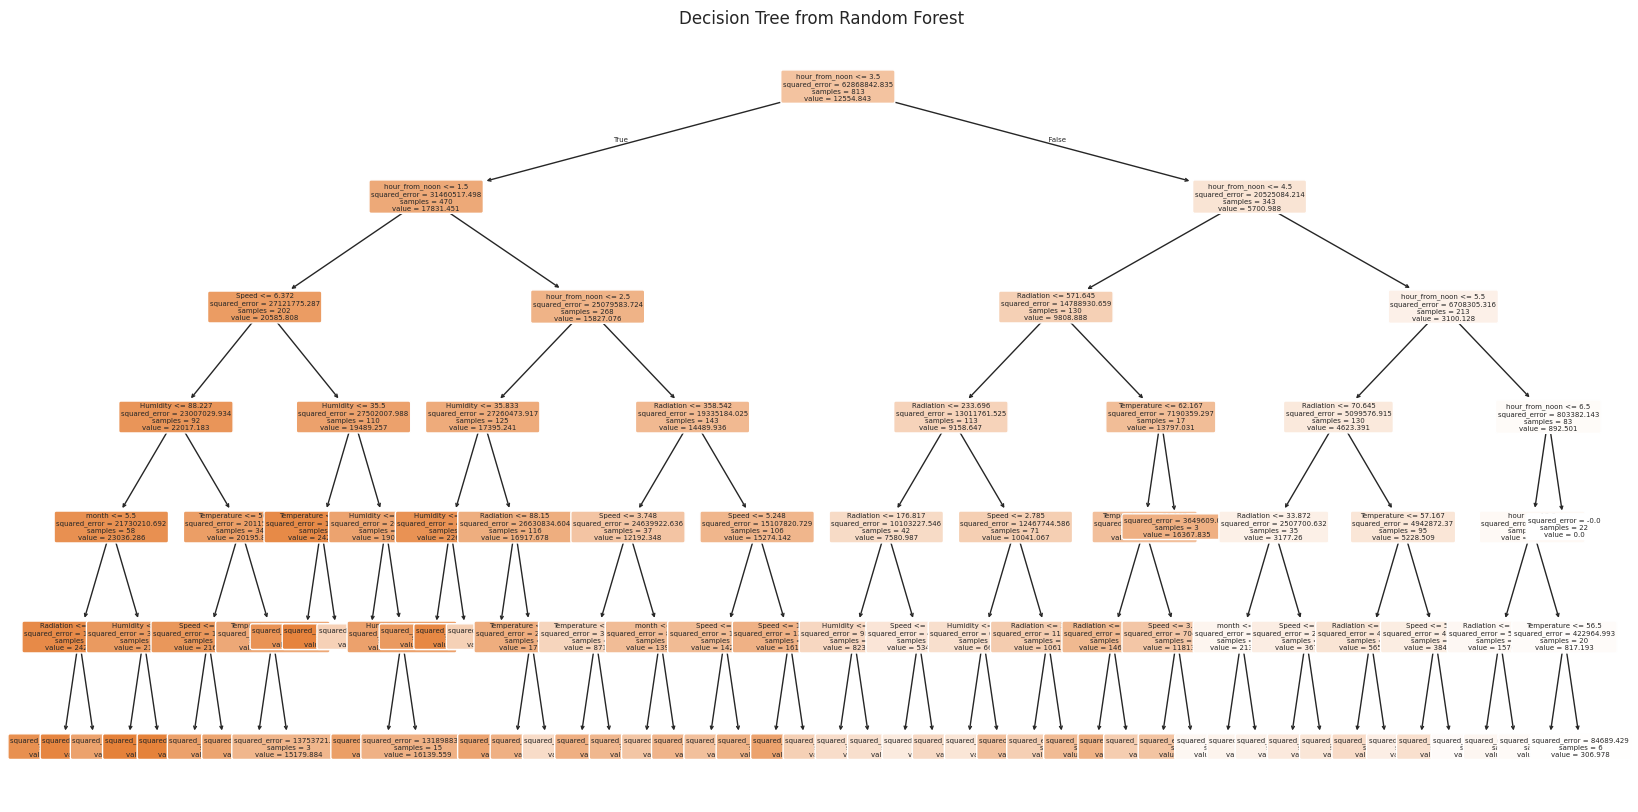

In [ ]:
# Plot one example decision tree from the Random Forest
tree_to_plot = models_p1['Random Forest'].estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_to_plot,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=5,
)
plt.title("Decision Tree from Random Forest")
plt.show()

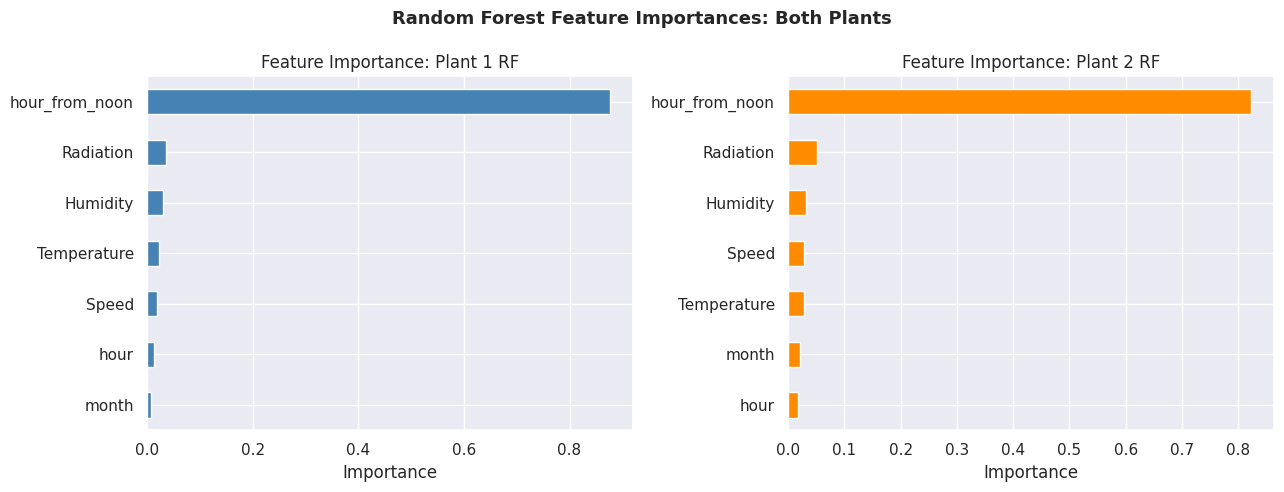

In [ ]:
# Feature Importance — Random Forest
rf_p1 = best_model_p1.named_steps['model'] if hasattr(best_model_p1, 'named_steps') else best_model_p1
rf_p2 = best_model_p2.named_steps['model'] if hasattr(best_model_p2, 'named_steps') else best_model_p2

imp_p1 = pd.Series(rf_p1.feature_importances_, index=FEATURES).sort_values()
imp_p2 = pd.Series(rf_p2.feature_importances_, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
imp_p1.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance: Plant 1 RF', fontsize=12)
axes[0].set_xlabel('Importance')

imp_p2.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance: Plant 2 RF', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle('Random Forest Feature Importances: Both Plants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Radiation and hour from noon are the most impactful weather conditions to the solar power generation. Although radiation is physically the main factor affecting solar power, the model assigns higher importance to hour_from_noon because it is a stable proxy for solar position.


## 7. Anomaly Detection – Flagging Underperforming Inverters

### Approach
For each inverter in a plant:

1. Aggregate inverter power data into daily performance metrics.
2. Normalize performance by comparing each inverter to the daily median of its peers to remove weather effects.
3. Construct peer-relative features such as relative performance, deviation, and variability.
4. Apply Isolation Forest on these features to detect anomalous inverter-day behaviour.
5. Rank inverters based on anomaly frequency to identify consistently underperforming units.
6. Visualise anomaly patterns and validate faults using heatmaps and time-series comparisons against peer benchmarks.

In [47]:
# PREPROCESSING

# --- Plant 1 ---
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True, errors='coerce')

p1_inv_day = p1.dropna(subset=['DATE_TIME', 'SOURCE_KEY', 'AC_POWER'])
p1_inv_day = p1_inv_day[p1_inv_day['AC_POWER'] >= 0].copy()
p1_inv_day['date'] = p1_inv_day['DATE_TIME'].dt.floor('D')

inv_daily_p1 = (
    p1_inv_day.groupby(['SOURCE_KEY', 'date'], as_index=False)
    .agg(
        total_AC=('AC_POWER', 'sum'),
        mean_AC=('AC_POWER', 'mean'),
        std_AC=('AC_POWER', 'std')
    )
)

# --- Plant 2 ---
p2['DATE_TIME'] = pd.to_datetime(p2['DATE_TIME'], errors='coerce')

p2_inv_day = p2.dropna(subset=['DATE_TIME', 'SOURCE_KEY', 'AC_POWER'])
p2_inv_day = p2_inv_day[p2_inv_day['AC_POWER'] >= 0].copy()
p2_inv_day['date'] = p2_inv_day['DATE_TIME'].dt.floor('D')

inv_daily_p2 = (
    p2_inv_day.groupby(['SOURCE_KEY', 'date'], as_index=False)
    .agg(
        total_AC=('AC_POWER', 'sum'),
        mean_AC=('AC_POWER', 'mean'),
        std_AC=('AC_POWER', 'std')
    )
)

# --- Common feature engineering ---
for df in [inv_daily_p1, inv_daily_p2]:
    df['std_AC'] = df['std_AC'].fillna(0)
    df['daily_median_AC'] = df.groupby('date')['total_AC'].transform('median')
    df['relative_to_peers'] = df['total_AC'] / (df['daily_median_AC'] + 1e-6)
    df['peer_residual'] = df['total_AC'] - df['daily_median_AC']
    df['peer_residual_pct'] = df['peer_residual'] / (df['daily_median_AC'] + 1e-6)
    df['date_str'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

# --- Display results ---
print('Plant 1 processed data shape:', inv_daily_p1.shape)
display(inv_daily_p1.head())

print('Plant 2 processed data shape:', inv_daily_p2.shape)
display(inv_daily_p2.head())

Plant 1 processed data shape: (748, 10)


,SOURCE_KEY,date,total_AC,mean_AC,std_AC,daily_median_AC,relative_to_peers,peer_residual,peer_residual_pct,date_str
0,1BY6WEcLGh8j5v7,2020-05-15,23046.550595,247.812372,308.465446,25347.116071,0.909238,-2300.565476,-0.090762,2020-05-15
1,1BY6WEcLGh8j5v7,2020-05-16,25124.491072,285.505580,343.059055,25824.573214,0.972891,-700.082142,-0.027109,2020-05-16
2,1BY6WEcLGh8j5v7,2020-05-17,28172.850000,293.467187,377.925595,30005.730953,0.938916,-1832.880953,-0.061084,2020-05-17
3,1BY6WEcLGh8j5v7,2020-05-18,19970.507143,208.026116,297.572033,21517.616071,0.928100,-1547.108929,-0.071900,2020-05-18
4,1BY6WEcLGh8j5v7,2020-05-19,22741.176786,244.528783,328.998506,24695.220536,0.920874,-1954.043750,-0.079126,2020-05-19


Plant 2 processed data shape: (716, 10)


,SOURCE_KEY,date,total_AC,mean_AC,std_AC,daily_median_AC,relative_to_peers,peer_residual,peer_residual_pct,date_str
0,4UPUqMRk7TRMgml,2020-05-15,16744.078571,176.253459,322.201229,35107.773095,0.476934,-18363.694524,-0.523066,2020-05-15
1,4UPUqMRk7TRMgml,2020-05-16,22791.219048,237.408532,368.787185,27762.021905,0.820950,-4970.802857,-0.179050,2020-05-16
2,4UPUqMRk7TRMgml,2020-05-17,25430.422381,264.900233,359.041722,25676.543095,0.990415,-246.120714,-0.009585,2020-05-17
3,4UPUqMRk7TRMgml,2020-05-18,30516.029524,317.875308,437.820119,26659.605952,1.144654,3856.423571,0.144654,2020-05-18
4,4UPUqMRk7TRMgml,2020-05-19,7878.389048,89.527148,171.451222,25924.976891,0.303892,-18046.587843,-0.696108,2020-05-19


In [48]:
# Anomaly Detection: ISOLATION FOREST

features = ['relative_to_peers', 'peer_residual_pct', 'std_AC']

rank_results = []

for df in [inv_daily_p1, inv_daily_p2]:

    scaled = MinMaxScaler().fit_transform(df[features].fillna(0))

    iso = IsolationForest(n_estimators=200, contamination=0.10, random_state=42)
    df['is_anomaly'] = iso.fit_predict(scaled) == -1

    rank = (
        df.groupby('SOURCE_KEY', as_index=False)
        .agg(
            anomaly_days=('is_anomaly', 'sum'),
            total_days=('is_anomaly', 'count'),
            mean_relative_perf=('relative_to_peers', 'mean')
        )
    )

    rank['anomaly_rate'] = rank['anomaly_days'] / rank['total_days']
    rank = rank.sort_values('anomaly_rate', ascending=False)

    rank_results.append(rank)

rank_p1, rank_p2 = rank_results


# --- Display summary ---
print('--- Isolation Forest Summary ---')

for name, df in zip(['Plant 1', 'Plant 2'], [inv_daily_p1, inv_daily_p2]):
    anomaly_pct = df['is_anomaly'].mean() * 100
    print(f'{name}: {df["is_anomaly"].sum()} anomalies out of {len(df)} ({anomaly_pct:.1f}%)')


# --- Show rankings ---
print('\n--- Top Anomalous Inverters ---')

print('\nPlant 1:')
display(rank_p1.head())

print('\nPlant 2:')
display(rank_p2.head())


# --- Highlight worst inverter ---
print('\nWorst Inverter (Plant 1):', rank_p1.iloc[0]['SOURCE_KEY'])
print('Worst Inverter (Plant 2):', rank_p2.iloc[0]['SOURCE_KEY'])


--- Isolation Forest Summary ---
Plant 1: 75 anomalies out of 748 (10.0%)
Plant 2: 72 anomalies out of 716 (10.1%)

--- Top Anomalous Inverters ---

Plant 1:


,SOURCE_KEY,anomaly_days,total_days,mean_relative_perf,anomaly_rate
11,bvBOhCH3iADSZry,24,34,0.901580,0.705882
0,1BY6WEcLGh8j5v7,14,34,0.915258,0.411765
10,adLQvlD726eNBSB,11,34,1.027139,0.323529
1,1IF53ai7Xc0U56Y,4,34,1.013706,0.117647
4,McdE0feGgRqW7Ca,3,34,1.012066,0.088235



Plant 2:


,SOURCE_KEY,anomaly_days,total_days,mean_relative_perf,anomaly_rate
13,WcxssY2VbP4hApt,7,34,0.955327,0.205882
0,4UPUqMRk7TRMgml,6,34,0.987401,0.176471
10,Qf4GUc1pJu5T6c6,6,34,0.985785,0.176471
11,Quc1TzYxW2pYoWX,5,34,0.639938,0.147059
3,Et9kgGMDl729KT4,5,34,0.689013,0.147059



Worst Inverter (Plant 1): bvBOhCH3iADSZry
Worst Inverter (Plant 2): WcxssY2VbP4hApt


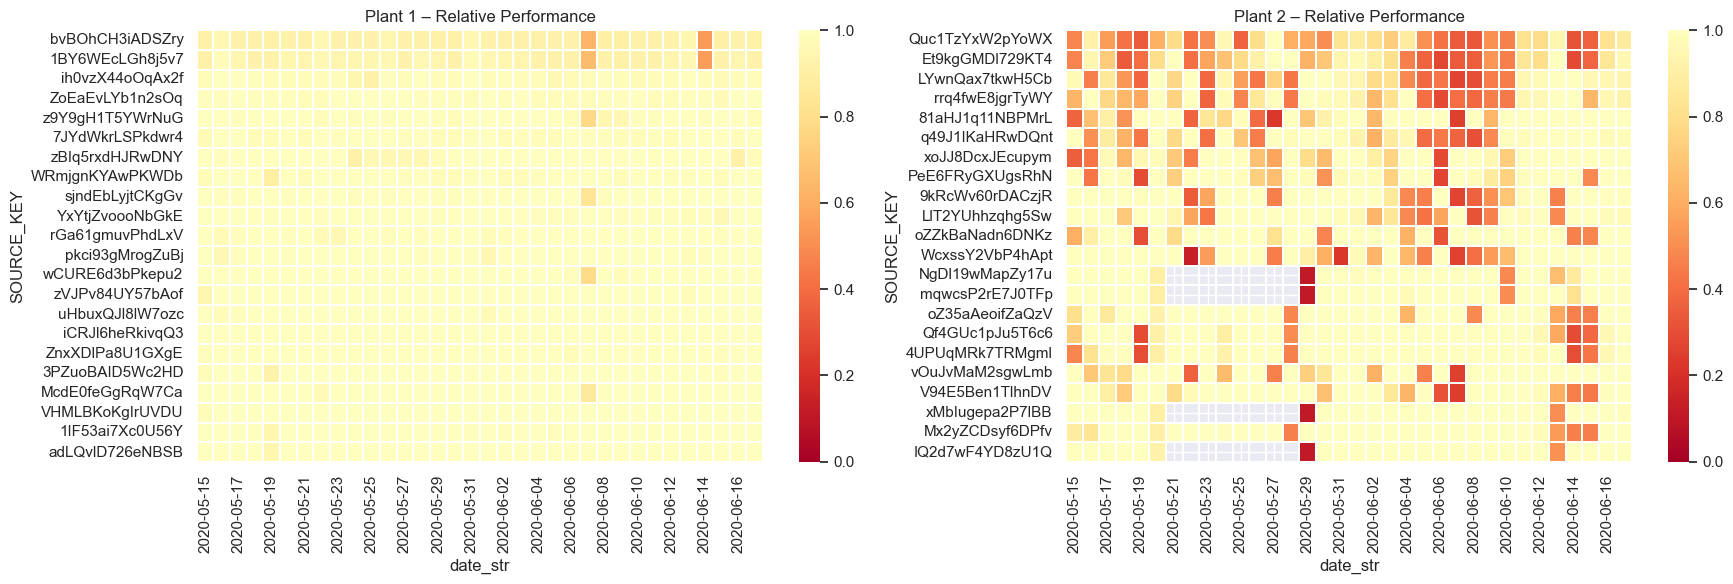

In [49]:
# Anomaly Visualisation: HEATMAP

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, title in zip(
    axes,
    [inv_daily_p1, inv_daily_p2],
    ['Plant 1', 'Plant 2']
):
    heatmap_matrix = df.pivot(index='SOURCE_KEY', columns='date_str', values='relative_to_peers')
    heatmap_order = heatmap_matrix.mean(axis=1).sort_values().index
    heatmap_matrix = heatmap_matrix.loc[heatmap_order]

    sns.heatmap(
        heatmap_matrix,
        cmap='RdYlGn',
        center=1,
        vmin=0,
        vmax=1.0,
        linewidths=0.2,
        ax=ax
    )

    ax.set_title(f'{title} – Relative Performance')

plt.tight_layout()
plt.show()

This heatmap shows each inverter’s performance relative to the daily median of all inverters in the two plants. Values close to 1 indicate normal performance, while lower values indicate underperformance. Persistent red regions highlight inverters that consistently perform worse than their peers.

<br>

It can be seen here that Plant 1 exhibits generally stable and consistent performance across all inverters, with only occasional short-term deviations, while Plant 2 shows significantly higher variability in inverter performance, with both underperforming and overperforming periods.

<br>

The presence of missing blocks in Plant 2's heatmap reflects the raw data on days where certain inverters had no recorded output. The possible reasons for such an observation could be offline inverters due to maintenance or failure, or data logging issue due to sensor failure or communication loss.

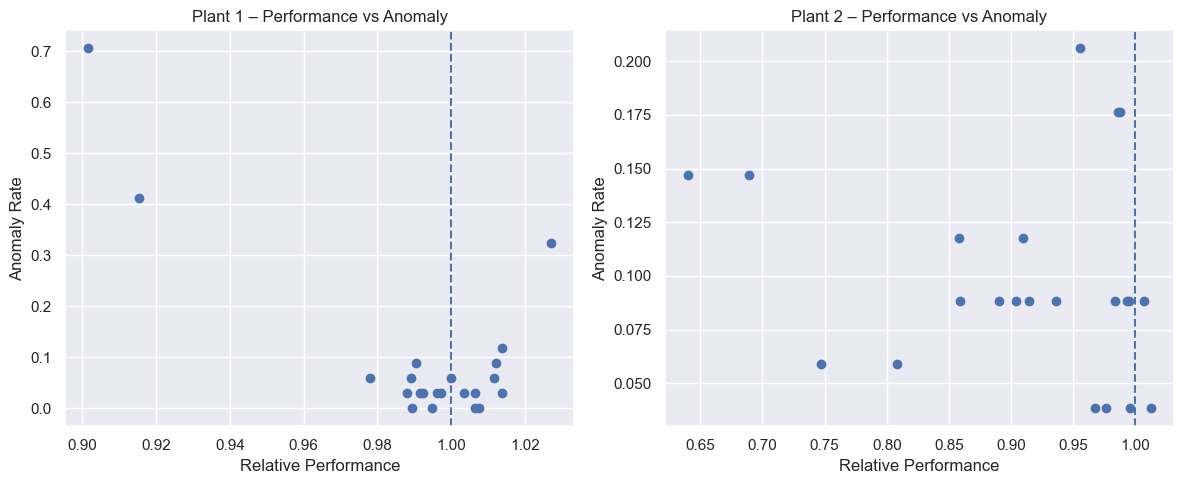

In [46]:
# Anomaly Visualisation: SCATTER of Relative Performance vs Anomaly Rate

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, rank, title in zip(
    axes,
    [rank_p1, rank_p2],
    ['Plant 1', 'Plant 2']
):
    ax.scatter(rank['mean_relative_perf'], rank['anomaly_rate'])
    ax.axvline(1.0, linestyle='--')

    ax.set_title(f'{title} – Performance vs Anomaly')
    ax.set_xlabel('Relative Performance')
    ax.set_ylabel('Anomaly Rate')

plt.tight_layout()
plt.show()

Plant 1 is generally stable, with most inverters performing close to the peer median and exhibiting low anomaly rates. However, a small number of inverters show significantly lower performance and high anomaly rates, indicating clear technical fault candidates.

<br>

On the other hand, Plant 2 exhibits greater variability in inverter performance, with a wider spread of relative performance values and moderate anomaly rates across multiple inverters, suggesting more widespread but less severe performance, which is concerning in terms of reliability.

<br>

Nevertheless, the plots prove that anomaly detection aligns with performance degradation.

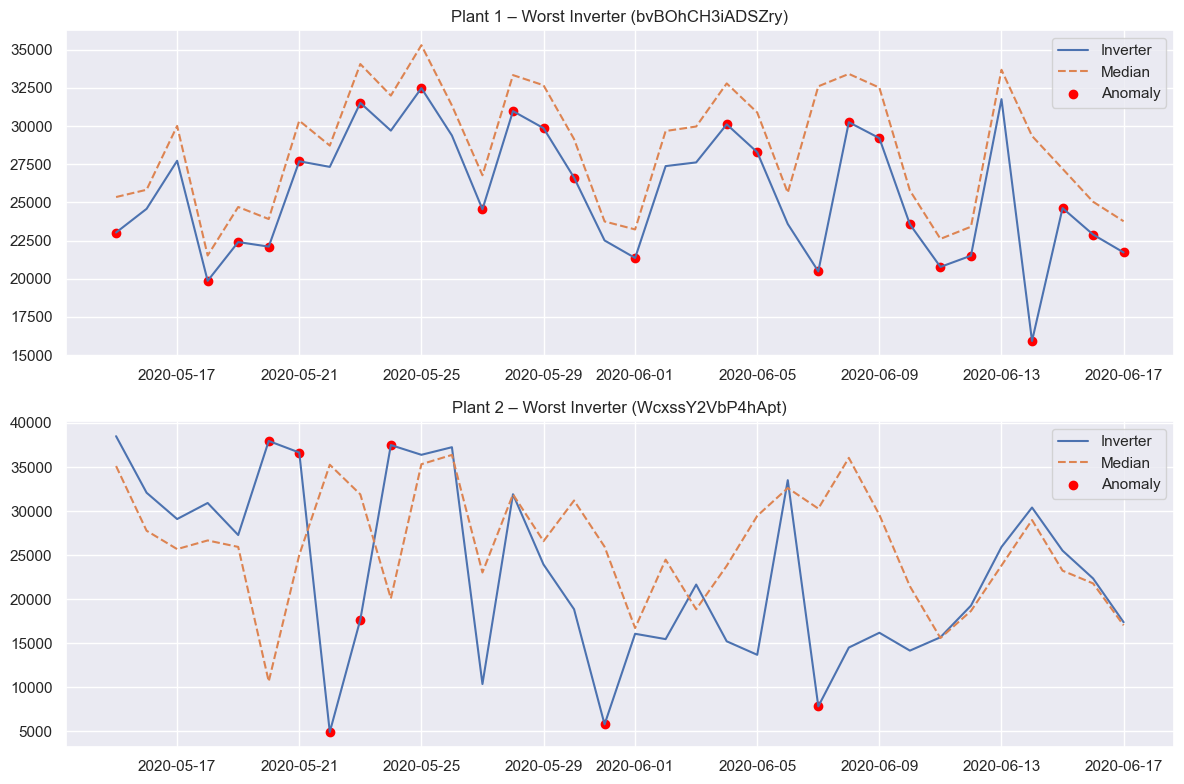

In [50]:
# Anomaly Visualisation: WORST INVERTER

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, df, rank, title in zip(
    axes,
    [inv_daily_p1, inv_daily_p2],
    [rank_p1, rank_p2],
    ['Plant 1', 'Plant 2']
):
    worst = rank.iloc[0]['SOURCE_KEY']
    worst_data = df[df['SOURCE_KEY'] == worst].sort_values('date')

    ax.plot(worst_data['date'], worst_data['total_AC'], label='Inverter')
    ax.plot(worst_data['date'], worst_data['daily_median_AC'], linestyle='--', label='Median')

    anomalies = worst_data[worst_data['is_anomaly']]
    ax.scatter(anomalies['date'], anomalies['total_AC'], color='red', label='Anomaly')

    ax.set_title(f'{title} – Worst Inverter ({worst})')
    ax.legend()

plt.tight_layout()
plt.show()

This plot compares the output of the worst-performing inverter with the daily median of its peers.

<br>

It can be observed that the detected anomalies align with significant drops in output relative to the median, confirming that the anomaly detection model successfully identifies meaningful underperformance.

<br>

The worst inverter in Plant 1 generally follows the overall system trend, but exhibits occasional sharp drops in output relative to the daily median, which are correctly identified as anomalies; the worst inverter in Plant 2 shows significant and frequent deviations from the peer median, including several extreme drops in output, indicating unstable and unreliable performance.


## 9. Summary & Conclusions

### Data Quality Findings (EDA highlight)
Two significant data recording issues were discovered and corrected before any modelling:

1. **Plant 1 DC_POWER unit mismatch** — DC/AC ratio of plant 1 is not plausible. The ratio was identical across all 22 inverters, indicating a unit recording difference for plant 1 DC.
To fix this, P1 DC was divided by a scale factor of 10.23. After correction both plants showed more realistic efficiency values.

3. **Plant 2 TOTAL_YIELD inaccuracy** — 16 of 22 inverters show values in the billions compared to Plant 1's maximum of 7.8 million. This data would create inaccuracies in comparisons and data analysis, therefore  TOTAL_YIELD was excluded from analysis, and DAILY_YIELD used instead.

### Regression Results
- Each plant was trained and evaluated on its own data — the plants have different capacities, with P1 generating ~1.31× more AC power per inverter at the same radiation, so cross-plant transfer is not valid.
- Cross-transfer failure: Applying a P1-trained model to P2 gave R squared ≈ 0 and negative R² for Random Forest. This showed that the plants cannot be predicted based off the same data.
- **Best model**: Random Forest — R^2 = **0.81 on Plant 1**, R^2 = **0.66 on Plant 2**.
- Radiation–AC correlation is weaker in P2 (0.52 vs P1's 0.63), meaning weather features explain less of P2's variance.
- **Top predictor**: Solar radiation and time of day dominates both plants, confirmed by feature importance on both models.

### Anomaly Detection Results
- **Isolation Forest** identified ~10% of inverter-days as anomalous in Plant 1.
- Persistent red rows in the inverter × date heatmap show a hardware fault.
- Full red columns would explain a weather event affecting all inverters.
- Top anomalous inverters would require a check-up: possible causes are shading, degraded cells, or inverter faults.


### What Was New / Beyond the Course
- **Isolation Forest** — unsupervised anomaly detection
- **Cross-transfer failure analysis** — physically motivated validation of model scope
- **Unit mismatch detection**
- **Counter overflow detection** — corrupted cumulative log identification via cross-plant comparison in TOTAL_YIELD
- **Time-series resampling** — `resample().interpolate()` to align multi-frequency datasets
- **Performance ratio KPI** — IEC 61724 standard metric for solar plant monitoring
